<a href="https://colab.research.google.com/github/DAGP1145/Mineriadedatos/blob/main/Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Acerca del Conjunto de Datos

Con la creciente competencia en el mercado minorista global, las empresas deben basarse en los datos para comprender mejor a sus clientes, productos y el rendimiento regional.

Este conjunto de datos contiene registros de ventas transaccionales de una supertienda global. Proporciona información detallada sobre pedidos, clientes, productos, envíos y rendimiento financiero.

El conjunto de datos puede utilizarse para explorar diversas cuestiones empresariales como:

1.  **¿Qué mercados y regiones generan más ventas y beneficios?**
2.  **¿Qué categorías o subcategorías de productos rinden mejor?**
3.  **¿Cómo afectan los descuentos a la rentabilidad?**
4.  **¿Qué modos y prioridades de envío se utilizan más comúnmente?**
5.  **¿Qué segmentos de clientes aportan más ingresos?**

Este conjunto de datos es adecuado para:

*   Análisis Exploratorio de Datos (EDA)
*   Paneles de control de Inteligencia Empresarial
*   Analítica de clientes y producto
*   Modelado de almacén de datos y esquemas estrellas

No dudes en explorar los datos y generar información que pueda ayudar a una empresa minorista a optimizar la oferta de productos, las estrategias de precios y las operaciones regionales.

# Descripción de las Columnas (para el Dataset de Supertienda)

A continuación, se detalla la descripción de cada columna en el dataset:

*   **`order_id`**: Identificador único para cada pedido.
*   **`order_date`**: Fecha en la que se realizó el pedido.
*   **`ship_date`**: Fecha en que se envió el pedido.
*   **`ship_mode`**: Método de envío elegido por el cliente (Clase Estándar, Segunda Clase, etc.).
*   **`customer_name`**: Nombre del cliente que realizó el pedido.
*   **`segment`**: Clasificación de segmentos de clientes (Consumidor, Corporativo, Oficina en Central).
*   **`state`**: Estado o provincia del cliente.
*   **`country`**: País donde se encuentra el cliente.
*   **`market`**: Agrupación de mercado que representa un área geográfica más amplia (por ejemplo, APAC, UE, EE. UU.).
*   **`region`**: Clasificación regional dentro de cada mercado.
*   **`product_id`**: Identificador único para cada producto.
*   **`category`**: Categoría de producto de alto nivel.
*   **`sub_category`**: Clasificación detallada del producto.
*   **`product_name`**: Nombre del producto.
*   **`sales`**: Valor total de ventas para la línea de pedidos.
*   **`quantity`**: Número de unidades compradas.
*   **`discount`**: Descuento aplicado al pedido.
*   **`profit`**: Ganancias o pérdidas generadas por la transacción.
*   **`shipping_cost`**: Coste incurrido para enviar el pedido.
*   **`order_priority`**: Nivel de prioridad asignado a la orden.
*   **`year`**: Año en que se realizó el pedido.

#Evaluacion 1

Objetivo de negocio y criterio de exito

**Objetivo de negocio:** identificar como `discount`, `sales` y `shipping_cost`, junto con `category`, `segment`, `market`, `ship_mode`, `order_priority`, `quantity` y `year`, se relacionan con `profit` para proponer decisiones comerciales y operativas que mejoren la rentabilidad.

**Criterio de exito para esta etapa:** completar EDA, limpieza y correlacion con resultados accionables y medibles:
- priorizar los **3 factores** con mayor relacion con `profit`;
- cuantificar su efecto esperado (direccion e intensidad de la relacion);
- dejar definidas hipotesis de negocio para la Evaluacion 2 (modelado) orientadas a reducir transacciones con margen negativo.

## Importación de librerías

In [ ]:
# Importacion centralizada de librerias
import pandas as pd  # Estructura y manipulacion de datos
import numpy as np  # Programacion vectorial

import kagglehub
from kagglehub import KaggleDatasetAdapter

import matplotlib.pyplot as plt
import seaborn as sns

## Carga de los datos



In [ ]:
# Set the path to the file you'd like to load
file_path = "SuperStoreOrders - SuperStoreOrders.csv"
# Esta variable se inicializa vacía. En el contexto de kagglehub.load_dataset,
# este file_path se usaría para especificar un archivo particular dentro de un
# dataset de Kaggle si el dataset contiene múltiples archivos y se desea cargar solo uno.
# Si se deja vacío, kagglehub intentará cargar el archivo principal o predeterminado.

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "thuandao/superstore-sales-analytics",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'superstore-sales-analytics' dataset.


## Analisis General

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

In [ ]:
print("Primeras 5 filas del DataFrame:")
display(df.head())

Primeras 5 filas del DataFrame:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [ ]:
print("\nInformación sobre tipos de datos:")
display(df.dtypes)


Información sobre tipos de datos:


,0
order_id,object
order_date,object
ship_date,object
ship_mode,object
customer_name,object
segment,object
state,object
country,object
market,object
region,object


In [ ]:
print('\nResumen de tipos informaticos por columna:')
display(df.dtypes.to_frame('dtype'))


Resumen de tipos informaticos por columna:


,dtype
order_id,object
order_date,object
ship_date,object
ship_mode,object
customer_name,object
segment,object
state,object
country,object
market,object
region,object


In [ ]:
print("\nEstadísticas descriptivas para columnas numéricas:")
df.describe().round(2)


Estadísticas descriptivas para columnas numéricas:


,quantity,discount,profit,shipping_cost,year
count,51290.00,51290.00,51290.00,51290.00,51290.00
mean,3.48,0.14,28.64,26.38,2012.78
std,2.28,0.21,174.42,57.30,1.10
min,1.00,0.00,-6599.98,0.00,2011.00
25%,2.00,0.00,0.00,2.61,2012.00
50%,3.00,0.00,9.24,7.79,2013.00
75%,5.00,0.20,36.81,24.45,2014.00
max,14.00,0.85,8399.98,933.57,2014.00


In [ ]:
print("\nConteo de valores nulos por columna:")
display(df.isnull().sum().sort_values(ascending=False))


Conteo de valores nulos por columna:


,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [ ]:
print("\nForma del DataFrame (filas, columnas):")
print(df.shape)


Forma del DataFrame (filas, columnas):
(51290, 21)


## Transformaciòn Inicial
Realizando conversiones de tipo de datos para 'sales', 'order_date' y 'ship_date' en un nuevo DataFrame

In [ ]:
df_borrador = df.copy()

In [ ]:
# Convertir 'sales' a numérico, manejando posibles errores
df_borrador['sales'] = pd.to_numeric(df_borrador['sales'], errors='coerce')

# Convertir 'order_date' y 'ship_date' a formato datetime ademàs de ajustarlo al formato del orden en que esta en el dataset
df_borrador['order_date'] = pd.to_datetime(df_borrador['order_date'], format='%d/%m/%Y')
df_borrador['ship_date'] = pd.to_datetime(df_borrador['ship_date'], format='%d/%m/%Y')

print("Conversiones completadas en 'df_borrador'. Verificando los tipos de datos actualizados:\n")
df_borrador.info()

Conversiones completadas en 'df_borrador'. Verificando los tipos de datos actualizados:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    5

In [ ]:
print("\nConteo de valores nulos por columna:")
display(df_borrador.isnull().sum().sort_values(ascending=False))


Conteo de valores nulos por columna:


,0
sales,2630
order_date,0
ship_date,0
ship_mode,0
order_id,0
customer_name,0
segment,0
country,0
state,0
region,0


## Analisis Detallado

### Valores Nulos en la Columna 'sales'

In [ ]:
print("Mostrando las filas donde la columna 'sales' es nula (NaN) en `df_borrador`:")
null_sales_rows = df_borrador[df_borrador['sales'].isnull()]

if not null_sales_rows.empty:
    print(f"Se encontraron {len(null_sales_rows)} filas con valores nulos en 'sales'.")
    print("Mostrando las primeras 10 filas con 'sales' nulas para su inspección:")
    display(null_sales_rows.head(10))
else:
    print("No se encontraron filas con valores nulos en la columna 'sales'.")

Mostrando las filas donde la columna 'sales' es nula (NaN) en `df_borrador`:
Se encontraron 2630 filas con valores nulos en 'sales'.
Mostrando las primeras 10 filas con 'sales' nulas para su inspección:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",NaN,6,0.0,609.8400,109.13,Medium,2011
43,MX-2011-109267,2011-01-05,2011-01-09,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,OFF-AP-10004245,Office Supplies,Appliances,"Hoover Stove, Black",NaN,8,0.0,999.3600,191.20,Medium,2011
58,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,NaN,9,0.0,746.4078,258.99,High,2011
83,AO-2011-1670,2011-01-08,2011-01-13,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,FUR-IKE-10001539,Furniture,Bookcases,"Ikea Classic Bookcase, Pine",NaN,6,0.0,49.5000,349.87,High,2011
84,IN-2011-19330,2011-01-08,2011-01-12,Second Class,Nicole Fjeld,Home Office,Yunnan,China,APAC,North Asia,TEC-MA-10002468,Technology,Machines,"Panasonic Inkjet, White",NaN,7,0.0,260.8200,275.52,Medium,2011
100,IN-2011-61302,2011-01-10,2011-01-11,First Class,Dan Lawera,Consumer,Queensland,Australia,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",NaN,5,0.1,511.0950,665.27,Medium,2011
125,ES-2011-5158390,2011-01-11,2011-01-11,Same Day,Roy Collins,Consumer,England,United Kingdom,EU,North,FUR-CH-10004255,Furniture,Chairs,"SAFCO Executive Leather Armchair, Red",NaN,3,0.0,13.7700,178.98,Medium,2011
126,US-2011-163874,2011-01-11,2011-01-12,First Class,Philip Fox,Consumer,México,Mexico,LATAM,North,OFF-ST-10003741,Office Supplies,Storage,"Smead Lockers, Blue",NaN,10,0.0,238.0000,103.84,Medium,2011
163,EG-2011-4270,2011-01-13,2011-01-18,Standard Class,Roger Demir,Consumer,Aswan,Egypt,Africa,Africa,TEC-HP -10001574,Technology,Copiers,"HP Fax Machine, Laser",NaN,4,0.0,479.8800,55.62,Medium,2011
173,CA-2011-157147,2011-01-14,2011-01-19,Standard Class,Brian Dahlen,Consumer,California,United States,US,West,OFF-ST-10000078,Office Supplies,Storage,Tennsco 6- and 18-Compartment Lockers,NaN,5,0.0,238.6530,187.65,High,2011


### Valores `sales` en `df` para `order_id`s con `sales` Nulos en `df_borrador`

In [ ]:
print("Consultando el dataset original 'df' para los 'sales' de los 'order_id's con valores nulos en 'df_borrador':")

order_ids_with_null_sales = null_sales_rows['order_id'].tolist()

# Filtrar el DataFrame original 'df' por estos order_ids y mostrar la columna 'sales'
original_sales_for_nulls = df[df['order_id'].isin(order_ids_with_null_sales)][['order_id', 'sales']]
display(original_sales_for_nulls.head(10))

Consultando el dataset original 'df' para los 'sales' de los 'order_id's con valores nulos en 'df_borrador':


,order_id,sales
27,MX-2011-111255,"1,648"
31,MX-2011-111255,149
43,MX-2011-109267,"3,029"
58,CA-2011-167199,"2,574"
59,CA-2011-167199,610
60,CA-2011-167199,392
67,CA-2011-167199,756
78,CA-2011-167199,31
79,CA-2011-167199,7
81,CA-2011-167199,5


In [ ]:
print("\nRealizando conversiones de tipo de datos para 'sales'")

# Limpiar la columna 'sales' eliminando comas antes de convertir a numérico
df_borrador['sales'] = df['sales'].astype(str).str.replace(',', '', regex=False)

# Convertir 'sales' a numérico, manejando posibles errores
df_borrador['sales'] = pd.to_numeric(df_borrador['sales'], errors='coerce')

print("Conversiones completadas en 'df_borrador'. Verificando los tipos de datos actualizados:")
df_borrador['sales'].info()
print("\nConteo de valores nulos por columna:")
display(df_borrador['sales'].isnull().sum())


Realizando conversiones de tipo de datos para 'sales'
Conversiones completadas en 'df_borrador'. Verificando los tipos de datos actualizados:
<class 'pandas.core.series.Series'>
RangeIndex: 51290 entries, 0 to 51289
Series name: sales
Non-Null Count  Dtype
--------------  -----
51290 non-null  int64
dtypes: int64(1)
memory usage: 400.8 KB

Conteo de valores nulos por columna:


np.int64(0)

### Profit Negativos

In [ ]:
print("Filtrando `df_borrador` para encontrar transacciones con 'profit' negativo...")
negative_profit_df = df_borrador[df_borrador['profit'] < 0]

if not negative_profit_df.empty:
    print(f"\n Se encontraron {len(negative_profit_df)} filas con 'profit' negativo.\n")
else:
    print("No se encontraron filas con 'profit' negativo.")

Filtrando `df_borrador` para encontrar transacciones con 'profit' negativo...

 Se encontraron 12543 filas con 'profit' negativo.



In [ ]:
# Frecuencias absolutas y relativas de variables categoricas clave
variables_categoricas_clave = ['market', 'segment', 'category', 'ship_mode', 'order_priority']

for col in variables_categoricas_clave:
    print(f'\n--- Frecuencias de {col} ---')
    tabla_frecuencias = df_borrador[col].value_counts(dropna=False).to_frame('frecuencia')
    tabla_frecuencias['proporcion'] = (
        df_borrador[col].value_counts(normalize=True, dropna=False).round(4)
    )
    display(tabla_frecuencias)


--- Frecuencias de market ---


,frecuencia,proporcion
market,,
APAC,11002,0.2145
LATAM,10294,0.2007
EU,10000,0.1950
US,9994,0.1949
EMEA,5029,0.0981
Africa,4587,0.0894
Canada,384,0.0075



--- Frecuencias de segment ---


,frecuencia,proporcion
segment,,
Consumer,26518,0.5170
Corporate,15429,0.3008
Home Office,9343,0.1822



--- Frecuencias de category ---


,frecuencia,proporcion
category,,
Office Supplies,31273,0.6097
Technology,10141,0.1977
Furniture,9876,0.1926



--- Frecuencias de ship_mode ---


,frecuencia,proporcion
ship_mode,,
Standard Class,30775,0.6000
Second Class,10309,0.2010
First Class,7505,0.1463
Same Day,2701,0.0527



--- Frecuencias de order_priority ---


,frecuencia,proporcion
order_priority,,
Medium,29433,0.5739
High,15501,0.3022
Critical,3932,0.0767
Low,2424,0.0473


## Graficos

### Top categorias por Ventas dentro de Cada Categoría

A continuación, generaremos un gráfico para cada una de las categorías principales (`category`), mostrando las subcategorias que más ganancias han generado dentro de esa categoría específica.

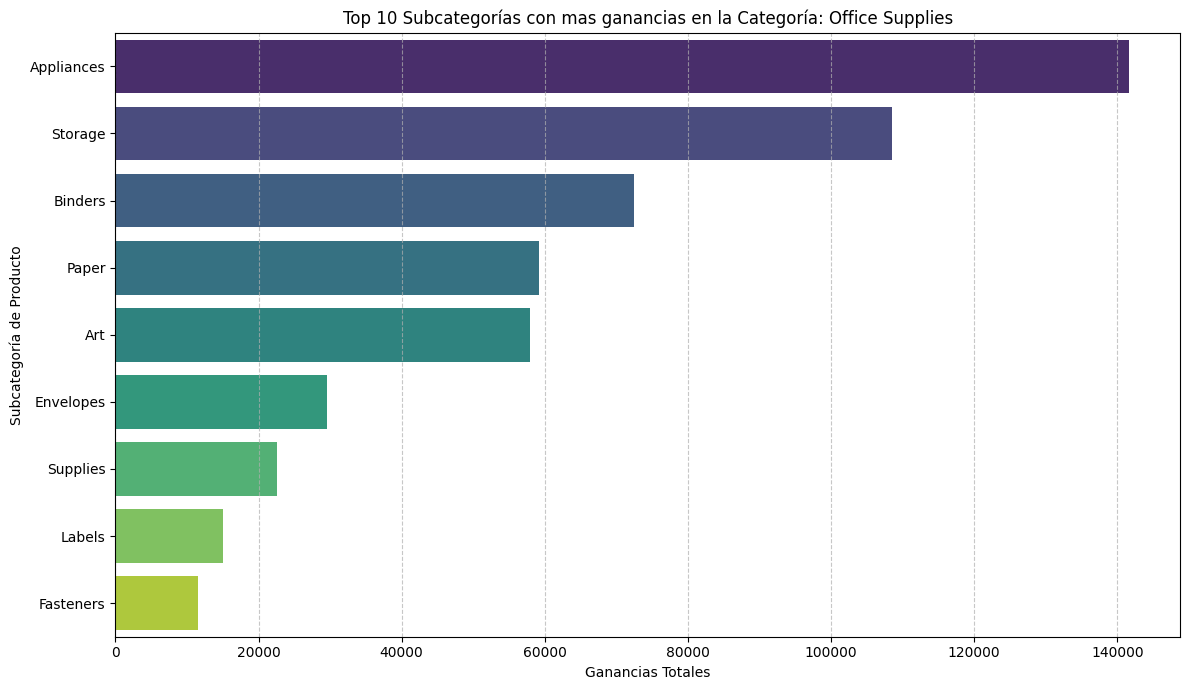


------------------------------



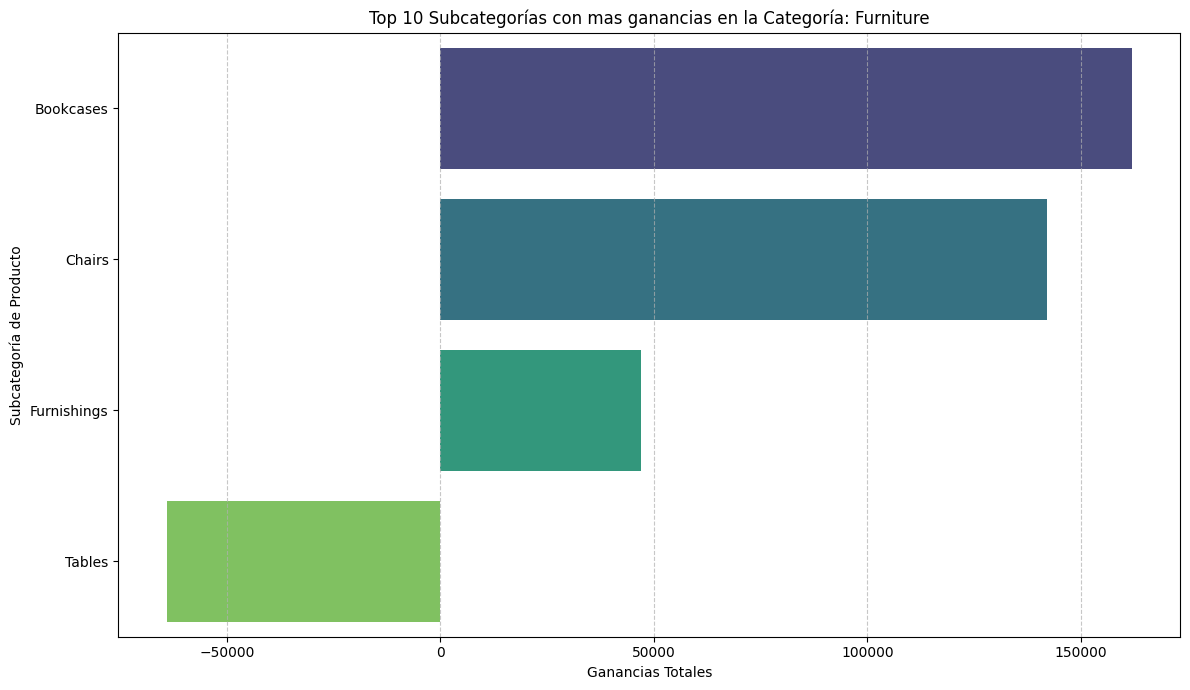


------------------------------



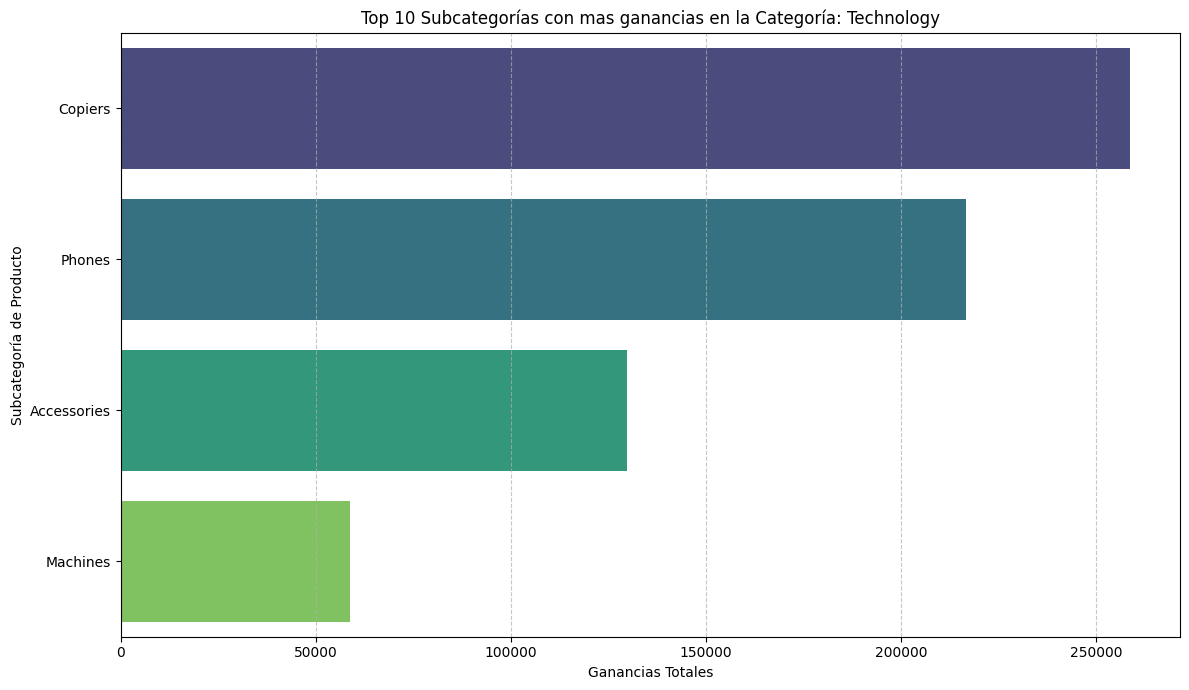


------------------------------



In [ ]:
unique_categories = df_borrador['category'].unique()

for category in unique_categories:
    # Filtrar el DataFrame para la categoría actual
    df_category = df_borrador[df_borrador['category'] == category]

    # Agrupar por sub_category y sumar las ventas dentro de esta categoría
    top_10_subcategories_in_category = df_category.groupby('sub_category')['profit'].sum().nlargest(10).reset_index()

    if not top_10_subcategories_in_category.empty:
        # Crear el gráfico de barras
        plt.figure(figsize=(12, 7))
        sns.barplot(x='profit', y='sub_category', data=top_10_subcategories_in_category, palette='viridis', hue='sub_category', legend=False)
        plt.title(f'Top 10 Subcategorías con mas ganancias en la Categoría: {category}')
        plt.xlabel('Ganancias Totales')
        plt.ylabel('Subcategoría de Producto')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        plt.close() # Close the plot to prevent them from stacking
        print("\n" + "---"*10 + "\n") # Add a visible separator between plots
    else:
        print(f"No hay datos de ventas para la categoría: {category}")

### Ganancias por Subcategoría de Producto

Finalmente, visualizaremos las ganancias por subcategoría para identificar las subcategorías de productos más vendidas.

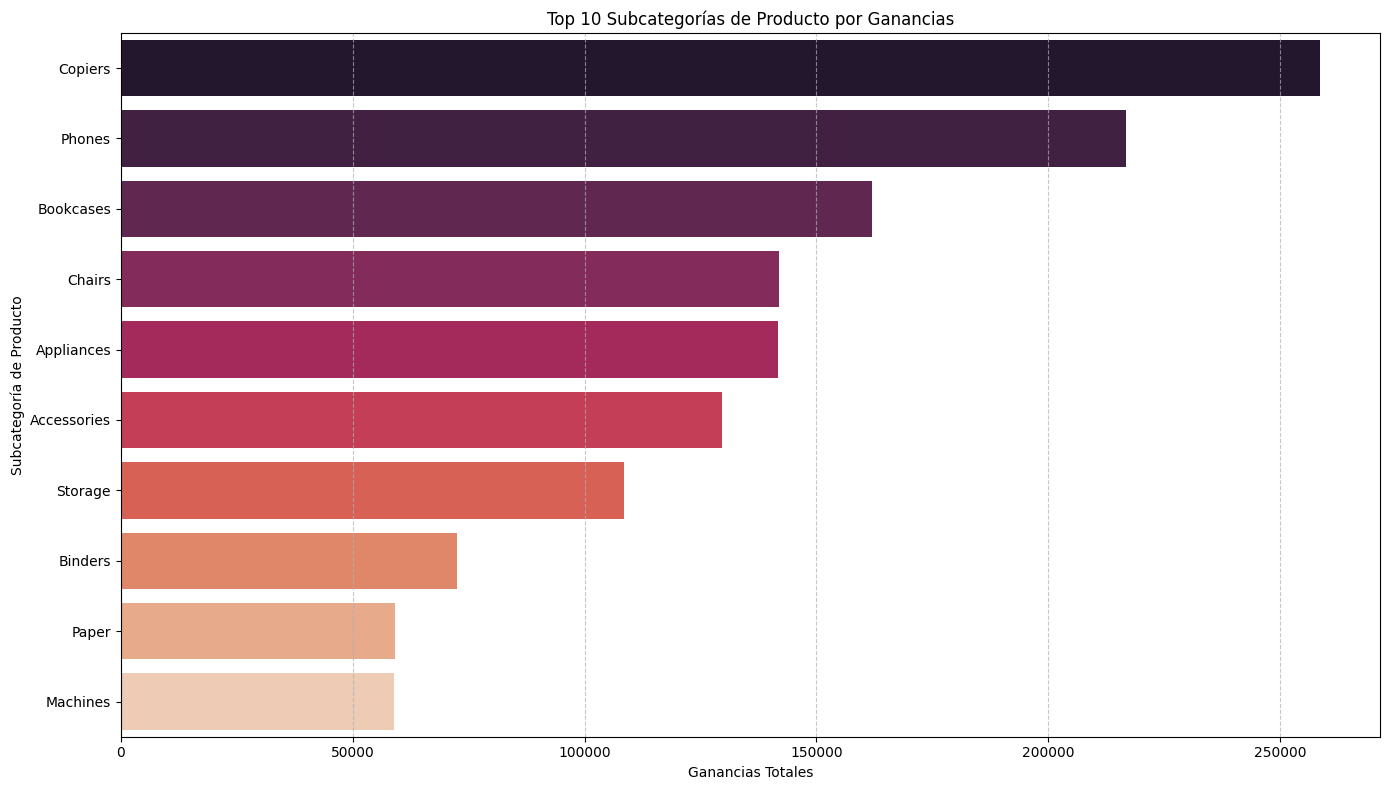

In [ ]:
# Calcular las ventas totales por subcategoría de producto y tomar las 10 principales para una mejor visualización
sales_by_subcategory = df_borrador.groupby('sub_category')['profit'].sum().nlargest(10).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='profit', y='sub_category', data=sales_by_subcategory, palette='rocket', hue='sub_category', legend=False)
plt.title('Top 10 Subcategorías de Producto por Ganancias')
plt.xlabel('Ganancias Totales')
plt.ylabel('Subcategoría de Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ganancias Percibidas por Producto (Top 10)

Ahora, vamos a identificar y visualizar los 10 productos que han generado mayores ganancias.

In [ ]:
# Agrupar por nombre de producto y sumar las ganancias
top_10_profitable_products = df_borrador.groupby('product_name')['profit'].sum().nlargest(10).reset_index()
top_10_profitable_products.columns = ['product_name', 'total_profit']

print("Top 10 Productos Más Rentables:")
display(top_10_profitable_products)

Top 10 Productos Más Rentables:


,product_name,total_profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,"Cisco Smart Phone, Full Size",17238.5206
2,"Motorola Smart Phone, Full Size",17027.1130
3,"Hoover Stove, Red",11807.9690
4,"Sauder Classic Bookcase, Traditional",10672.0730
5,"Harbour Creations Executive Leather Armchair, ...",10427.3260
6,"Nokia Smart Phone, Full Size",9938.1955
7,"Cisco Smart Phone, with Caller ID",9786.6408
8,"Nokia Smart Phone, with Caller ID",9465.3257
9,"Belkin Router, USB",8955.0180


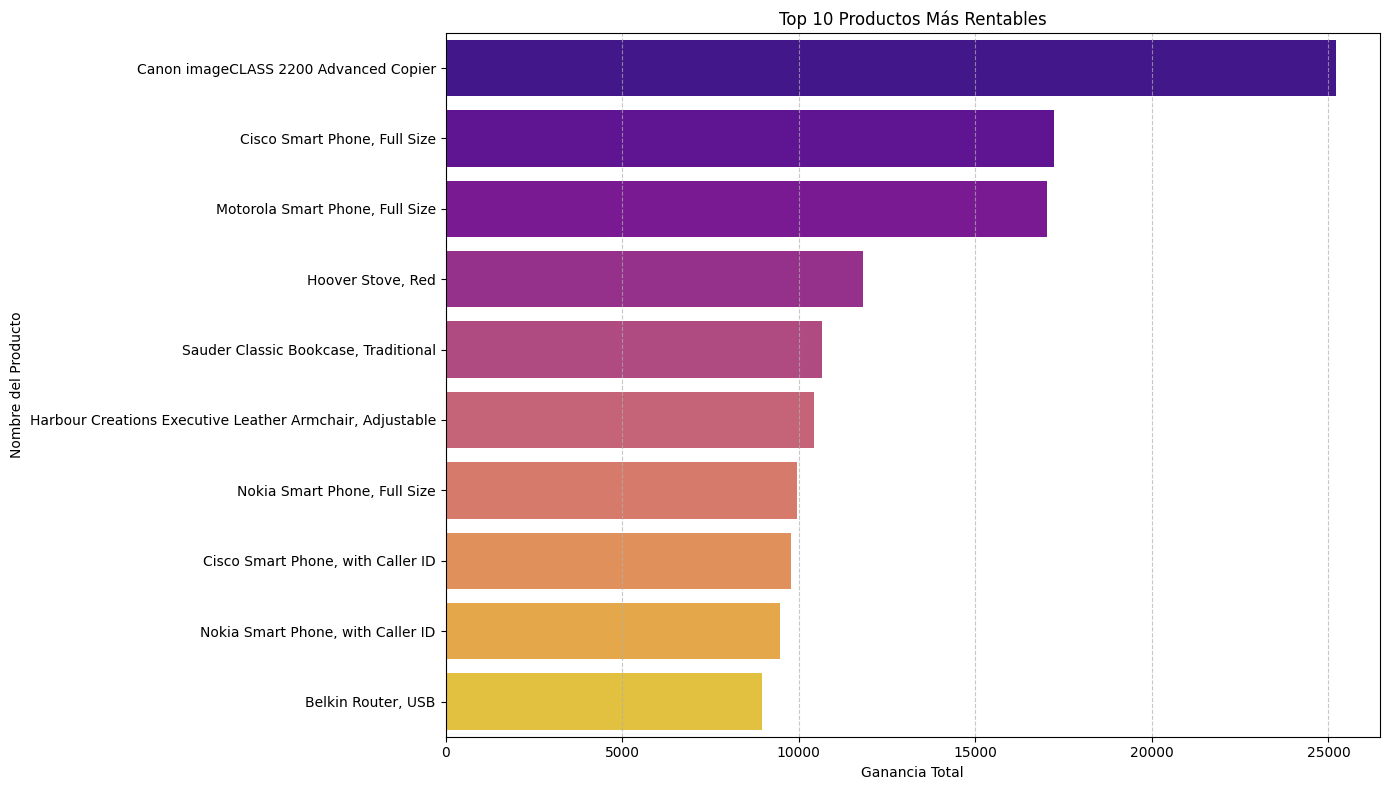

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(x='total_profit', y='product_name', data=top_10_profitable_products, palette='plasma', hue='product_name', legend=False)
plt.title('Top 10 Productos Más Rentables')
plt.xlabel('Ganancia Total')
plt.ylabel('Nombre del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Frecuencia de los 10 Productos Más Vendidos

Vamos a visualizar los 10 productos que se han vendido en mayor cantidad.

In [ ]:
# Agrupar por nombre de producto y sumar la cantidad vendida
top_10_products = df_borrador.groupby('product_name')['quantity'].sum().nlargest(10).reset_index()
top_10_products.columns = ['product_name', 'total_quantity_sold']

print("Top 10 Productos Más Vendidos por Cantidad:")
display(top_10_products)

Top 10 Productos Más Vendidos por Cantidad:


,product_name,total_quantity_sold
0,Staples,876
1,"Cardinal Index Tab, Clear",337
2,"Eldon File Cart, Single Width",321
3,"Rogers File Cart, Single Width",262
4,"Sanford Pencil Sharpener, Water Color",259
5,"Stockwell Paper Clips, Assorted Sizes",253
6,"Avery Index Tab, Clear",252
7,"Ibico Index Tab, Clear",251
8,"Smead File Cart, Single Width",250
9,"Stanley Pencil Sharpener, Water Color",242


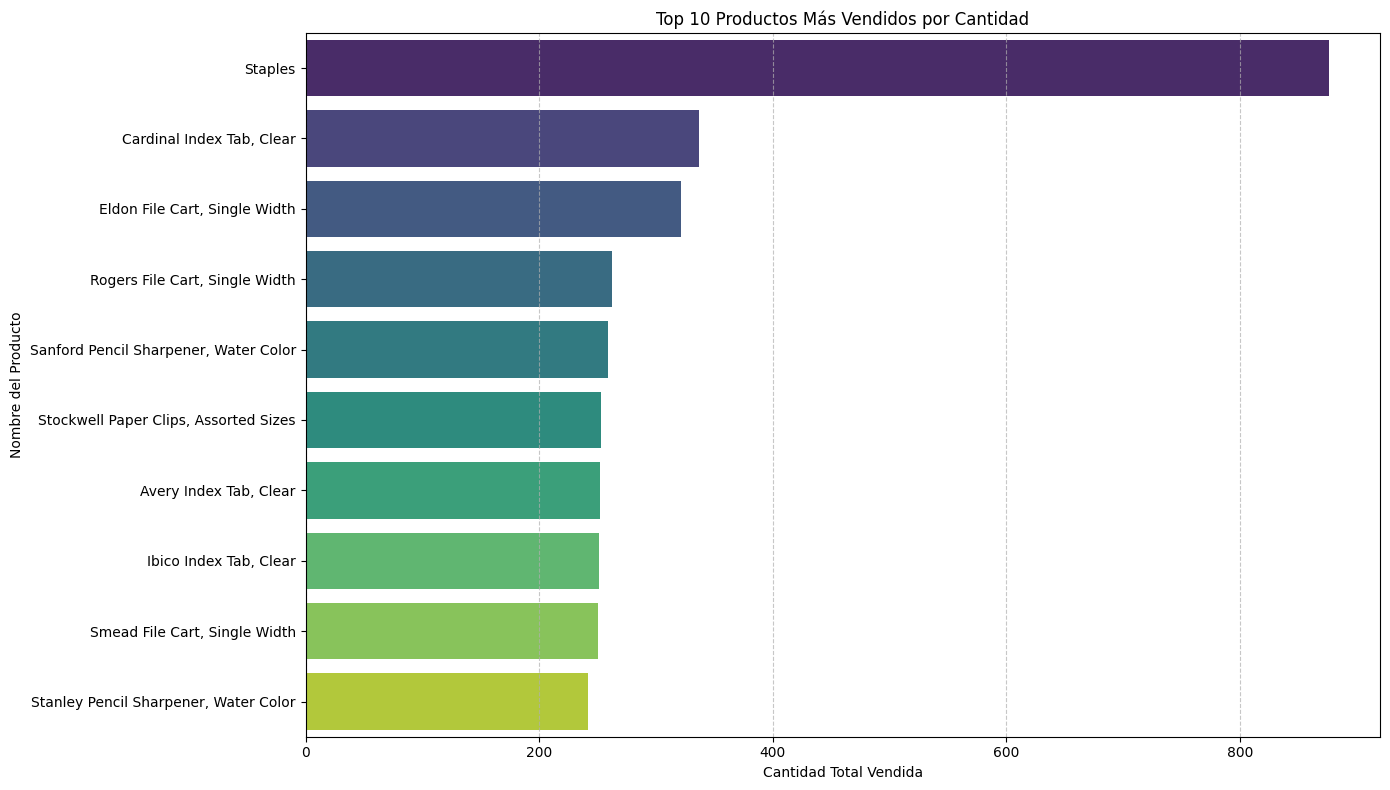

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(x='total_quantity_sold', y='product_name', data=top_10_products, palette='viridis', hue='product_name', legend=False)
plt.title('Top 10 Productos Más Vendidos por Cantidad')
plt.xlabel('Cantidad Total Vendida')
plt.ylabel('Nombre del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Influencia de Categorías de Producto por Mercado

Vamos a explorar qué categorías de productos tienen mayor impacto (en términos de ventas) dentro de cada mercado. Esto nos ayudará a entender las preferencias regionales.

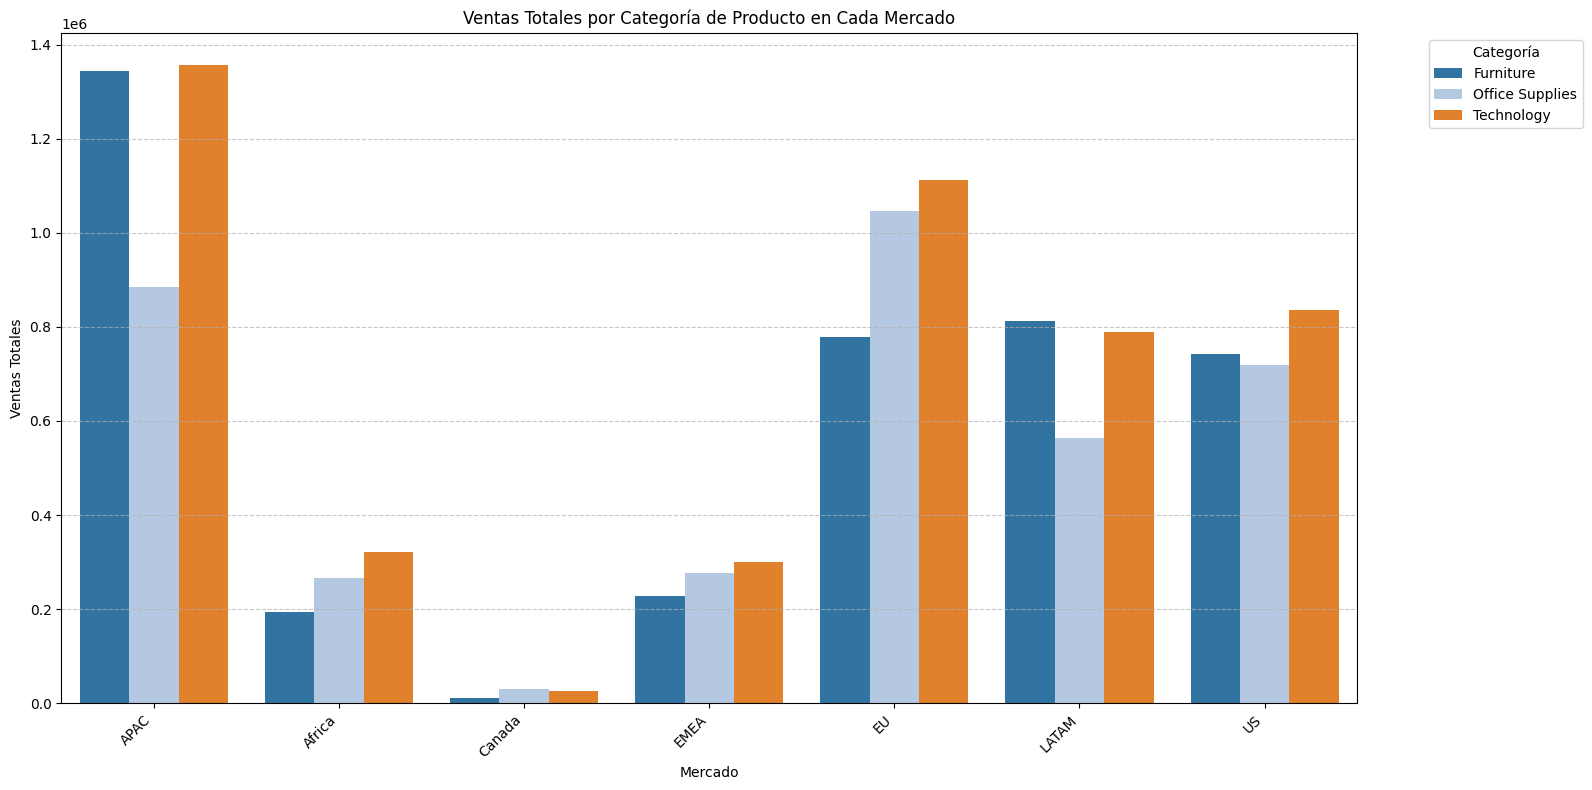

In [ ]:
# Calcular las ventas totales por categoría y mercado
sales_by_market_category = df_borrador.groupby(['market', 'category'])['sales'].sum().reset_index()

# Crear un gráfico de barras apiladas para visualizar la distribución de ventas por categoría en cada mercado
plt.figure(figsize=(16, 8))
sns.barplot(x='market', y='sales', hue='category', data=sales_by_market_category, palette='tab20')
plt.title('Ventas Totales por Categoría de Producto en Cada Mercado')
plt.xlabel('Mercado')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ventas Totales por Categoría de Producto por Segmento de Cliente

Este gráfico muestra cómo se distribuyen las ventas de las diferentes categorías de productos dentro de cada segmento de cliente, permitiéndonos identificar las preferencias de compra de cada grupo.

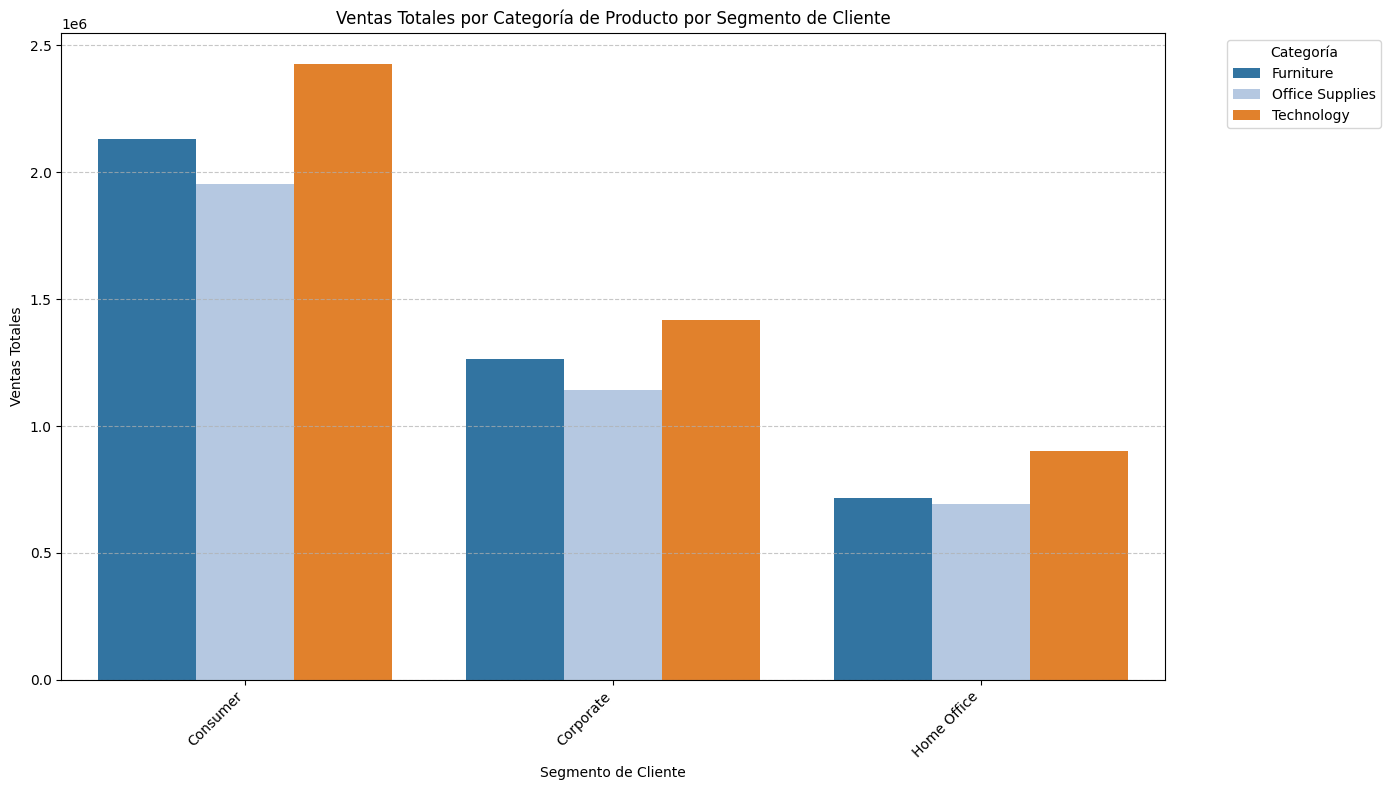

In [ ]:
# Agrupar por segmento y categoría, y sumar las ventas
sales_by_segment_category = df_borrador.groupby(['segment', 'category'])['sales'].sum().reset_index()

# Crear el gráfico de barras apiladas
plt.figure(figsize=(14, 8))
sns.barplot(x='segment', y='sales', hue='category', data=sales_by_segment_category, palette='tab20')
plt.title('Ventas Totales por Categoría de Producto por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ventas por Segmento de Cliente

Ahora, analizaremos cómo se distribuyen las ventas entre los diferentes segmentos de clientes para identificar cuáles son los más lucrativos.

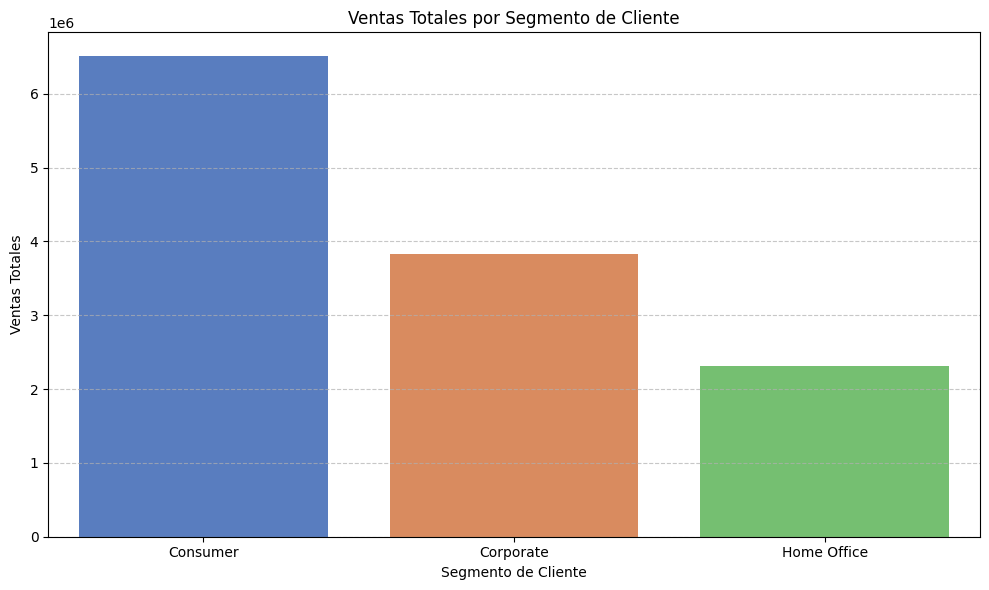

In [ ]:
# Calcular las ventas totales por segmento de cliente
sales_by_segment = df_borrador.groupby('segment')['sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='segment', y='sales', data=sales_by_segment, palette='muted', hue='segment', legend=False)
plt.title('Ventas Totales por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Ventas Totales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Costo de Envío por Modo de Envío

Vamos a visualizar la distribución del `shipping_cost` para cada `ship_mode` utilizando un boxplot.

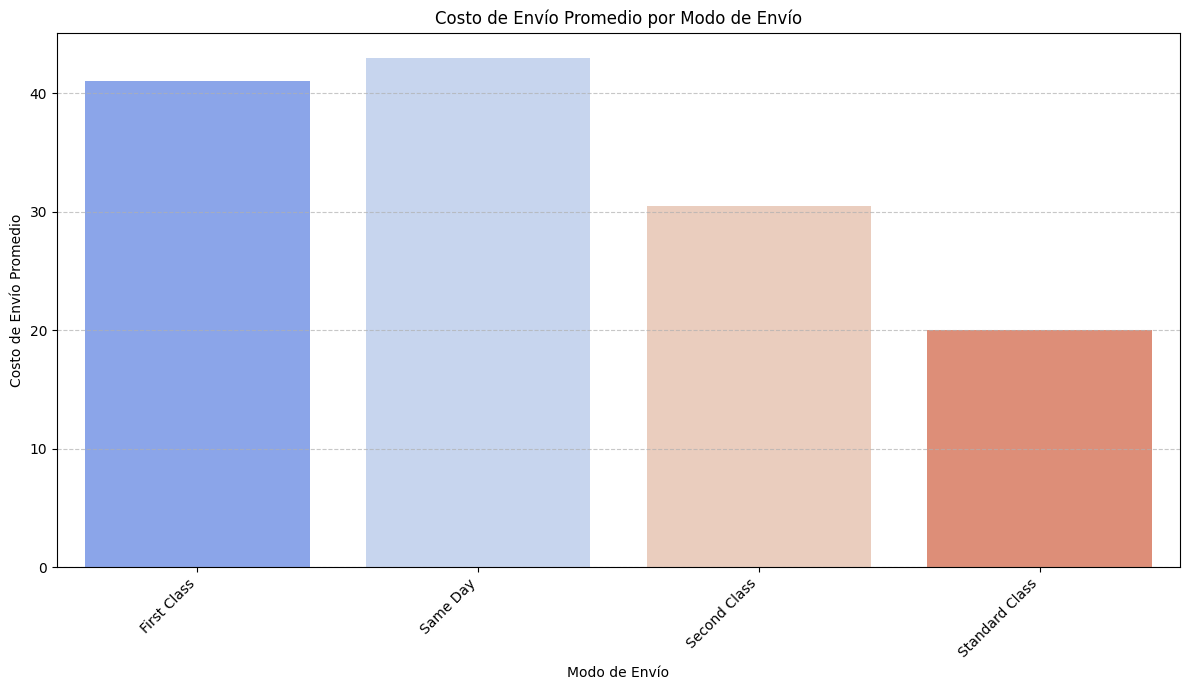

In [ ]:
plt.figure(figsize=(12, 7))
mean_shipping_cost_by_mode = df_borrador.groupby('ship_mode')['shipping_cost'].mean().reset_index()
sns.barplot(x='ship_mode', y='shipping_cost', data=mean_shipping_cost_by_mode, palette='coolwarm', hue='ship_mode', legend=False)
plt.title('Costo de Envío Promedio por Modo de Envío')
plt.xlabel('Modo de Envío')
plt.ylabel('Costo de Envío Promedio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Proporción de Modos de Envío por Segmento de Cliente

Vamos a explorar las preferencias de `ship_mode` dentro de cada `segment` de cliente.

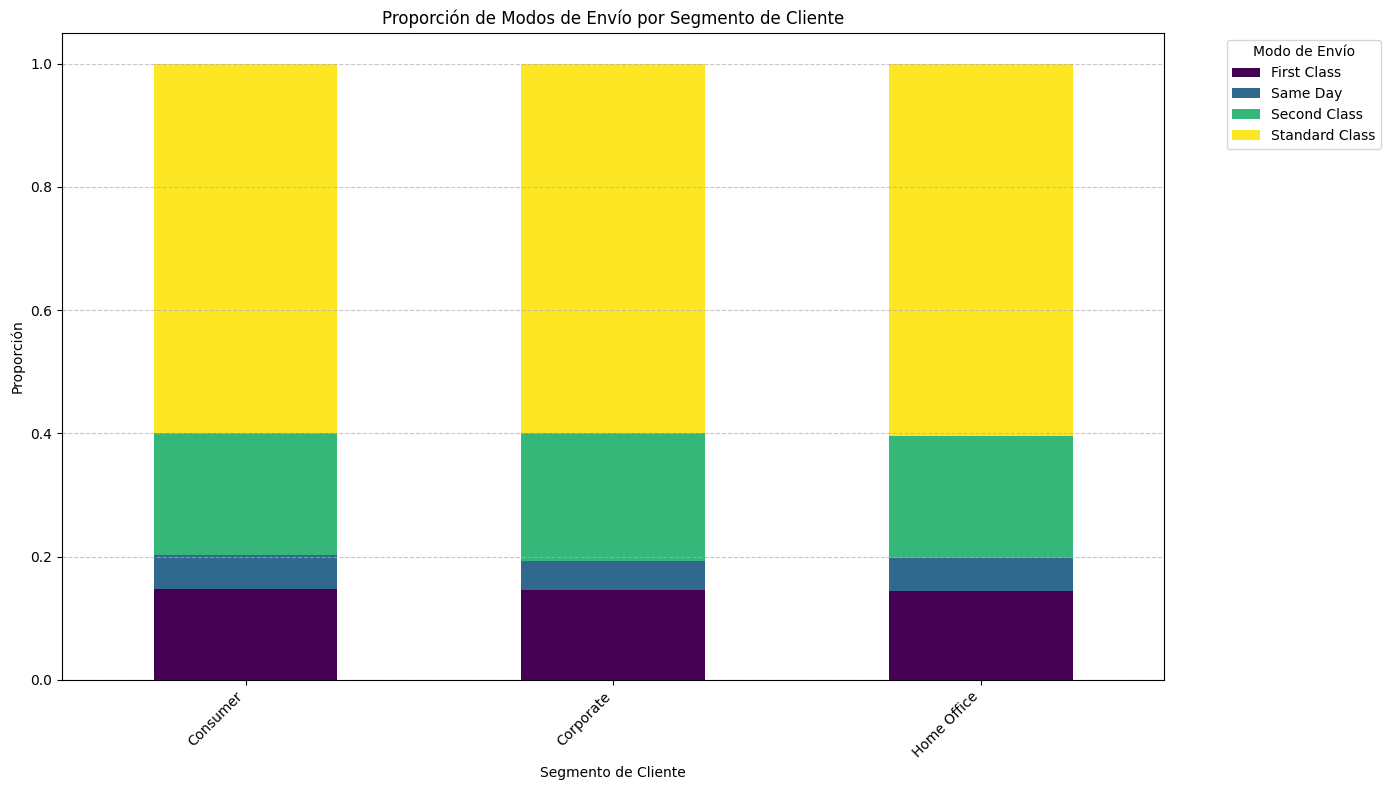

In [ ]:
# Calcular la proporción de cada ship_mode por segmento de cliente directamente usando crosstab
ship_mode_segment_proportions = pd.crosstab(df_borrador['segment'], df_borrador['ship_mode'], normalize='index')

# Plotear el gráfico de barras apiladas
ship_mode_segment_proportions.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Proporción de Modos de Envío por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modo de Envío', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Proporción de Modos de Envío por Mercado

Para entender las preferencias de `ship_mode` en cada `market`, crearemos un gráfico de barras apiladas.

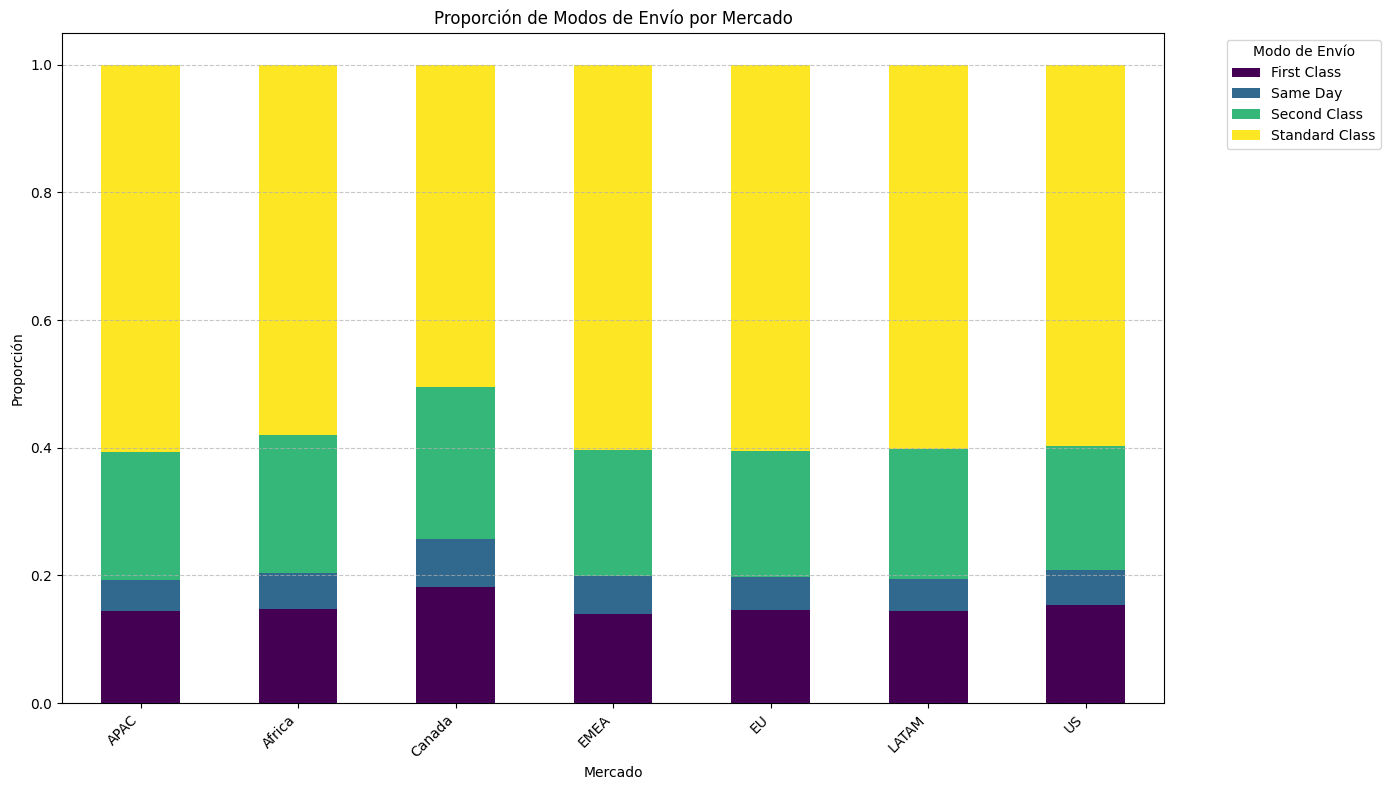

In [ ]:
# Calcular la frecuencia de cada ship_mode por market
ship_mode_market_counts = df_borrador.groupby(['market', 'ship_mode']).size().unstack(fill_value=0)

# Convertir a proporciones para el gráfico apilado
ship_mode_market_proportions = ship_mode_market_counts.apply(lambda x: x / x.sum(), axis=1)

# Plotear el gráfico de barras apiladas
ship_mode_market_proportions.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Proporción de Modos de Envío por Mercado')
plt.xlabel('Mercado')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modo de Envío', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

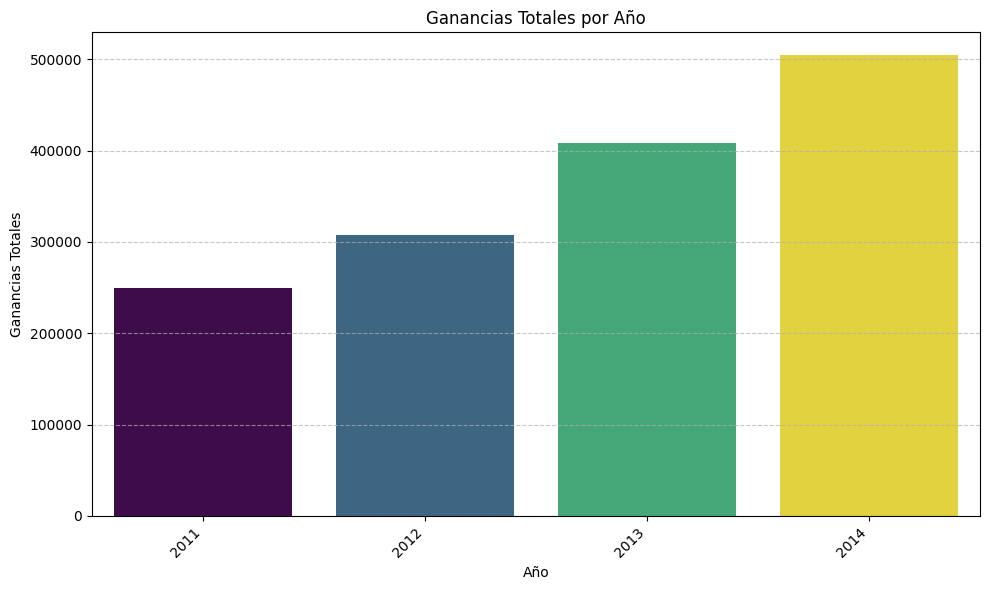

In [ ]:
sales_by_year = df_borrador.groupby('year')['profit'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='year', y='profit', data=sales_by_year, palette='viridis', hue='year', legend=False)
plt.title('Ganancias Totales por Año')
plt.xlabel('Año')
plt.ylabel('Ganancias Totales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Dataset de negocio reducido

Los graficos anteriores incluyen una **exploracion descriptiva previa**, incluso con algunas vistas de mayor detalle como subcategoria o producto. Esas visualizaciones sirven como contexto exploratorio, pero **no forman parte del dataset base del objetivo de negocio**.

A partir de este punto trabajaremos con una version reducida del dataset, conservando solo las variables alineadas con el objetivo de negocio y dejando afuera el detalle excesivo.

In [ ]:
# Variables seleccionadas para el objetivo de negocio
variables_negocio = [
    'profit', 'discount', 'sales', 'shipping_cost', 'quantity',
    'category', 'segment', 'market', 'ship_mode', 'order_priority', 'year'
]

df_negocio = df_borrador[variables_negocio].copy()

# Variable derivada util para analisis posterior de precios y outliers
df_negocio['precio_unidad'] = np.where(
    df_negocio['discount'] == 1,
    df_negocio['sales'] / df_negocio['quantity'],
    df_negocio['sales'] / (df_negocio['quantity'] * (1 - df_negocio['discount']))
)

print('Forma original de df_borrador:', df_borrador.shape)
print('Forma del dataset de negocio reducido:', df_negocio.shape)
print('\nColumnas conservadas:')
print(df_negocio.columns.tolist())

# Desde este punto el resto del cuaderno trabaja con la version reducida
df_borrador = df_negocio.copy()
display(df_borrador.head())

Forma original de df_borrador: (51290, 21)
Forma del dataset de negocio reducido: (51290, 12)

Columnas conservadas:
['profit', 'discount', 'sales', 'shipping_cost', 'quantity', 'category', 'segment', 'market', 'ship_mode', 'order_priority', 'year', 'precio_unidad']


,profit,discount,sales,shipping_cost,quantity,category,segment,market,ship_mode,order_priority,year,precio_unidad
0,106.140,0.0,408,35.46,2,Office Supplies,Consumer,Africa,Standard Class,Medium,2011,204.000000
1,36.036,0.1,120,9.72,3,Office Supplies,Consumer,APAC,Standard Class,Medium,2011,44.444444
2,29.640,0.0,66,8.17,4,Office Supplies,Consumer,EMEA,Second Class,High,2011,16.500000
3,-26.055,0.5,45,4.82,3,Office Supplies,Home Office,EU,Second Class,High,2011,30.000000
4,37.770,0.1,114,4.70,5,Furniture,Consumer,APAC,Standard Class,Medium,2011,25.333333


## OUTLIERS

### Análisis de Outliers en `sales`

Vamos a identificar y cuantificar los outliers en la columna `sales` utilizando el método del rango intercuartílico (IQR)

In [ ]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_sales = df_borrador['sales'].quantile(0.25)
Q3_sales = df_borrador['sales'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_sales = Q3_sales - Q1_sales

# Definir los límites para identificar outliers
lower_bound_sales = Q1_sales - 1.5 * IQR_sales
upper_bound_sales = Q3_sales + 1.5 * IQR_sales

# Identificar los outliers
outliers_sales = df_borrador[(df_borrador['sales'] < lower_bound_sales) | (df_borrador['sales'] > upper_bound_sales)]

print(f"Q1 (25th percentile) para 'sales': {Q1_sales:.2f}")
print(f"Q3 (75th percentile) para 'sales': {Q3_sales:.2f}")
print(f"IQR para 'sales': {IQR_sales:.2f}")
print(f"Lower Bound para Outliers en 'sales': {lower_bound_sales:.2f}")
print(f"Upper Bound para Outliers en 'sales': {upper_bound_sales:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'sales': {len(outliers_sales)}")
print(f"Porcentaje de outliers en 'sales': {(len(outliers_sales) / len(df_borrador) * 100):.2f}%")


Q1 (25th percentile) para 'sales': 31.00
Q3 (75th percentile) para 'sales': 251.00
IQR para 'sales': 220.00
Lower Bound para Outliers en 'sales': -299.00
Upper Bound para Outliers en 'sales': 581.00

Número total de filas: 51290
Número de outliers en 'sales': 5655
Porcentaje de outliers en 'sales': 11.03%


### Análisis de Outliers en `profit`

Vamos a identificar y cuantificar los outliers en la columna `profit` utilizando el método del rango intercuartílico (IQR).

In [ ]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil) para 'profit'
Q1_profit = df_borrador['profit'].quantile(0.25)
Q3_profit = df_borrador['profit'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR) para 'profit'
IQR_profit = Q3_profit - Q1_profit

# Definir los límites para identificar outliers en 'profit'
lower_bound_profit = Q1_profit - 1.5 * IQR_profit
upper_bound_profit = Q3_profit + 1.5 * IQR_profit

# Identificar los outliers en 'profit'
outliers_profit = df_borrador[(df_borrador['profit'] < lower_bound_profit) | (df_borrador['profit'] > upper_bound_profit)]

print(f"Q1 (25th percentile) para 'profit': {Q1_profit:.2f}")
print(f"Q3 (75th percentile) para 'profit': {Q3_profit:.2f}")
print(f"IQR para 'profit': {IQR_profit:.2f}")
print(f"Lower Bound para Outliers en 'profit': {lower_bound_profit:.2f}")
print(f"Upper Bound para Outliers en 'profit': {upper_bound_profit:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'profit': {len(outliers_profit)}")
print(f"Porcentaje de outliers en 'profit': {(len(outliers_profit) / len(df_borrador) * 100):.2f}%")

Q1 (25th percentile) para 'profit': 0.00
Q3 (75th percentile) para 'profit': 36.81
IQR para 'profit': 36.81
Lower Bound para Outliers en 'profit': -55.22
Upper Bound para Outliers en 'profit': 92.03

Número total de filas: 51290
Número de outliers en 'profit': 9755
Porcentaje de outliers en 'profit': 19.02%


### Análisis de Outliers en `quantity`

Vamos a identificar y cuantificar los outliers en la columna `quantity` utilizando el método del rango intercuartílico (IQR).

In [ ]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_quantity = df_borrador['quantity'].quantile(0.25)
Q3_quantity = df_borrador['quantity'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_quantity = Q3_quantity - Q1_quantity

# Definir los límites para identificar outliers
lower_bound_quantity = Q1_quantity - 1.5 * IQR_quantity
upper_bound_quantity = Q3_quantity + 1.5 * IQR_quantity

# Identificar los outliers
outliers_quantity = df_borrador[(df_borrador['quantity'] < lower_bound_quantity) | (df_borrador['quantity'] > upper_bound_quantity)]

print(f"Q1 (25th percentile) para 'quantity': {Q1_quantity:.2f}")
print(f"Q3 (75th percentile) para 'quantity': {Q3_quantity:.2f}")
print(f"IQR para 'quantity': {IQR_quantity:.2f}")
print(f"Lower Bound para Outliers en 'quantity': {lower_bound_quantity:.2f}")
print(f"Upper Bound para Outliers en 'quantity': {upper_bound_quantity:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'quantity': {len(outliers_quantity)}")
print(f"Porcentaje de outliers en 'quantity': {(len(outliers_quantity) / len(df_borrador) * 100):.2f}%")

Q1 (25th percentile) para 'quantity': 2.00
Q3 (75th percentile) para 'quantity': 5.00
IQR para 'quantity': 3.00
Lower Bound para Outliers en 'quantity': -2.50
Upper Bound para Outliers en 'quantity': 9.50

Número total de filas: 51290
Número de outliers en 'quantity': 877
Porcentaje de outliers en 'quantity': 1.71%


### Análisis de Outliers en `shipping_cost`

Vamos a identificar y cuantificar los outliers en la columna `shipping_cost` utilizando el método del rango intercuartílico (IQR).

In [ ]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_shipping_cost = df_borrador['shipping_cost'].quantile(0.25)
Q3_shipping_cost = df_borrador['shipping_cost'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_shipping_cost = Q3_shipping_cost - Q1_shipping_cost

# Definir los límites para identificar outliers
lower_bound_shipping_cost = Q1_shipping_cost - 1.5 * IQR_shipping_cost
upper_bound_shipping_cost = Q3_shipping_cost + 1.5 * IQR_shipping_cost

# Identificar los outliers
outliers_shipping_cost = df_borrador[
    (df_borrador['shipping_cost'] < lower_bound_shipping_cost) |
    (df_borrador['shipping_cost'] > upper_bound_shipping_cost)
]

print(f"Q1 (25th percentile) para 'shipping_cost': {Q1_shipping_cost:.2f}")
print(f"Q3 (75th percentile) para 'shipping_cost': {Q3_shipping_cost:.2f}")
print(f"IQR para 'shipping_cost': {IQR_shipping_cost:.2f}")
print(f"Lower Bound para Outliers en 'shipping_cost': {lower_bound_shipping_cost:.2f}")
print(f"Upper Bound para Outliers en 'shipping_cost': {upper_bound_shipping_cost:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'shipping_cost': {len(outliers_shipping_cost)}")
print(f"Porcentaje de outliers en 'shipping_cost': {(len(outliers_shipping_cost) / len(df_borrador) * 100):.2f}%")

Q1 (25th percentile) para 'shipping_cost': 2.61
Q3 (75th percentile) para 'shipping_cost': 24.45
IQR para 'shipping_cost': 21.84
Lower Bound para Outliers en 'shipping_cost': -30.15
Upper Bound para Outliers en 'shipping_cost': 57.21

Número total de filas: 51290
Número de outliers en 'shipping_cost': 5909
Porcentaje de outliers en 'shipping_cost': 11.52%


### Análisis de Outliers en `discount`

Vamos a identificar y cuantificar los outliers en la columna `discount` utilizando el método del rango intercuartílico (IQR).

In [ ]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_discount = df_borrador['discount'].quantile(0.25)
Q3_discount = df_borrador['discount'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_discount = Q3_discount - Q1_discount

# Definir los límites para identificar outliers
lower_bound_discount = Q1_discount - 1.5 * IQR_discount
upper_bound_discount = Q3_discount + 1.5 * IQR_discount

# Identificar los outliers
outliers_discount = df_borrador[(df_borrador['discount'] < lower_bound_discount) | (df_borrador['discount'] > upper_bound_discount)]

print(f"Q1 (25th percentile) para 'discount': {Q1_discount:.2f}")
print(f"Q3 (75th percentile) para 'discount': {Q3_discount:.2f}")
print(f"IQR para 'discount': {IQR_discount:.2f}")
print(f"Lower Bound para Outliers en 'discount': {lower_bound_discount:.2f}")
print(f"Upper Bound para Outliers en 'discount': {upper_bound_discount:.2f}")
print(f"Minimo valor: {df_borrador['discount'].min():.2f}")
print(f"Maximo valor: {df_borrador['discount'].max():.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'discount': {len(outliers_discount)}")
print(f"Porcentaje de outliers en 'discount': {(len(outliers_discount) / len(df_borrador) * 100):.2f}%")

Q1 (25th percentile) para 'discount': 0.00
Q3 (75th percentile) para 'discount': 0.20
IQR para 'discount': 0.20
Lower Bound para Outliers en 'discount': -0.30
Upper Bound para Outliers en 'discount': 0.50
Minimo valor: 0.00
Maximo valor: 0.85

Número total de filas: 51290
Número de outliers en 'discount': 4172
Porcentaje de outliers en 'discount': 8.13%


### Análisis de Outliers en `precio_unidad`

Ahora, vamos a identificar y cuantificar los outliers en la columna `precio_unidad` utilizando el método del rango intercuartílico (IQR).

In [ ]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_precio_unidad = df_borrador['precio_unidad'].quantile(0.25)
Q3_precio_unidad = df_borrador['precio_unidad'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_precio_unidad = Q3_precio_unidad - Q1_precio_unidad

# Definir los límites para identificar outliers
lower_bound_precio_unidad = Q1_precio_unidad - 1.5 * IQR_precio_unidad
upper_bound_precio_unidad = Q3_precio_unidad + 1.5 * IQR_precio_unidad

# Identificar los outliers
outliers_precio_unidad = df_borrador[(df_borrador['precio_unidad'] < lower_bound_precio_unidad) | (df_borrador['precio_unidad'] > upper_bound_precio_unidad)]

print(f"Q1 (25th percentile) para 'precio_unidad': {Q1_precio_unidad:.2f}")
print(f"Q3 (75th percentile) para 'precio_unidad': {Q3_precio_unidad:.2f}")
print(f"IQR para 'precio_unidad': {IQR_precio_unidad:.2f}")
print(f"Lower Bound para Outliers en 'precio_unidad': {lower_bound_precio_unidad:.2f}")
print(f"Upper Bound para Outliers en 'precio_unidad': {upper_bound_precio_unidad:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'precio_unidad': {len(outliers_precio_unidad)}")
print(f"Porcentaje de outliers en 'precio_unidad': {(len(outliers_precio_unidad) / len(df_borrador) * 100):.2f}%")

Q1 (25th percentile) para 'precio_unidad': 14.12
Q3 (75th percentile) para 'precio_unidad': 103.50
IQR para 'precio_unidad': 89.38
Lower Bound para Outliers en 'precio_unidad': -119.96
Upper Bound para Outliers en 'precio_unidad': 237.57

Número total de filas: 51290
Número de outliers en 'precio_unidad': 5032
Porcentaje de outliers en 'precio_unidad': 9.81%


### Eliminacion global de outliers (antes de encoding y correlacion)

Siguiendo la indicacion metodologica, se eliminan directamente todas las filas que presenten outliers en variables numericas clave, para continuar con un dataset depurado.

In [ ]:
# Eliminacion global de outliers por IQR en variables clave (celda autosuficiente)
if 'df_borrador' not in globals():
    raise ValueError("No existe df_borrador. Ejecuta primero la seccion de transformacion inicial.")

# Asegurar columnas derivadas requeridas para el filtrado de outliers
if 'precio_unidad' not in df_borrador.columns:
    df_borrador['precio_unidad'] = np.where(
        df_borrador['discount'] == 1,
        df_borrador['sales'] / df_borrador['quantity'],
        df_borrador['sales'] / (df_borrador['quantity'] * (1 - df_borrador['discount']))
)

variables_outlier = [
    'sales', 'shipping_cost', 'discount', 'precio_unidad', 'profit', 'quantity'
]

# Calcular limites IQR por variable
limites = {}
for col in variables_outlier:
    q1 = df_borrador[col].quantile(0.25)
    q3 = df_borrador[col].quantile(0.75)
    iqr = q3 - q1
    limites[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

# Marcar fila como outlier si es outlier en al menos una variable
any_outlier_condition = pd.Series(False, index=df_borrador.index)
for col in variables_outlier:
    lower, upper = limites[col]
    any_outlier_condition |= (df_borrador[col] < lower) | (df_borrador[col] > upper)

num_outliers_to_remove = int(any_outlier_condition.sum())
print(f"Filas con al menos un outlier: {num_outliers_to_remove}")

df_borrador_cleaned = df_borrador[~any_outlier_condition].copy()

print(f"Forma original del DataFrame: {df_borrador.shape}")
print(f"Nueva forma del DataFrame despues de eliminar outliers: {df_borrador_cleaned.shape}")
print(f"Se eliminaron {len(df_borrador) - len(df_borrador_cleaned)} filas.")

Filas con al menos un outlier: 15498
Forma original del DataFrame: (51290, 12)
Nueva forma del DataFrame despues de eliminar outliers: (35792, 12)
Se eliminaron 15498 filas.


### Conteo de Outliers por Variable Individual en el DataFrame Depurado (`df_borrador_cleaned`)

Ahora vamos a recalcular y mostrar el número de outliers restantes para cada variable numérica en el DataFrame después de la eliminación de los outliers combinados específicos.

In [ ]:
print("\n--- Conteo de Outliers Individuales en df_borrador_cleaned ---\n")

if 'df_borrador_cleaned' not in globals():
    raise ValueError("No existe df_borrador_cleaned. Ejecuta primero la celda de eliminacion global de outliers.")

# Debe coincidir exactamente con variables_outlier de la limpieza global
variables_revisar = ['sales', 'shipping_cost', 'discount', 'precio_unidad', 'profit', 'quantity']

# Resolver limites de forma robusta para no depender del estado del kernel
limites_locales = {}
for col in variables_revisar:
    if 'limites' in globals() and col in limites:
        limites_locales[col] = limites[col]
    else:
        base_df = df_borrador if 'df_borrador' in globals() and col in df_borrador.columns else df_borrador_cleaned
        q1 = base_df[col].quantile(0.25)
        q3 = base_df[col].quantile(0.75)
        iqr = q3 - q1
        limites_locales[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

for col in variables_revisar:
    lower, upper = limites_locales[col]
    outliers_col = df_borrador_cleaned[
        (df_borrador_cleaned[col] < lower) | (df_borrador_cleaned[col] > upper)
    ]
    print(f"Outliers en '{col}': {len(outliers_col)}")

print("\n------------------------------------------------\n")


--- Conteo de Outliers Individuales en df_borrador_cleaned ---

Outliers en 'sales': 0
Outliers en 'shipping_cost': 0
Outliers en 'discount': 0
Outliers en 'precio_unidad': 0
Outliers en 'profit': 0
Outliers en 'quantity': 0

------------------------------------------------



## Encoding de Variables (antes de correlacion)

Para mantener coherencia metodologica:

- `Label Encoding` se aplica solo a variables con orden logico: `order_priority` y `ship_mode`.
- `One-Hot Encoding` se aplica a variables nominales sin orden: `segment`, `category` y `market`.

De esta forma evitamos imponer ordinalidad artificial en variables categoricas nominales.

In [ ]:
# Crear una copia para evitar SettingWithCopyWarning
df_encoded = df_borrador_cleaned.copy()

# Encoding ordinal coherente (sin LabelEncoder para evitar codificacion ambigua)
df_encoded['order_priority_encoded'] = df_encoded['order_priority'].map({
    'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3
})
df_encoded['ship_mode_encoded'] = df_encoded['ship_mode'].map({
    'Same Day': 0, 'First Class': 1, 'Second Class': 2, 'Standard Class': 3
})

# Verificar que no queden valores sin mapear
if df_encoded[['order_priority_encoded', 'ship_mode_encoded']].isnull().any().any():
    raise ValueError('Hay categorias no contempladas en el mapeo ordinal.')

df_encoded[['order_priority_encoded', 'ship_mode_encoded']] = (
    df_encoded[['order_priority_encoded', 'ship_mode_encoded']].astype(int)
)

print("Encoding ordinal aplicado correctamente:")
print("order_priority -> Low<Medium<High<Critical")
print("ship_mode -> Same Day<First Class<Second Class<Standard Class")
display(df_encoded[['order_priority', 'order_priority_encoded', 'ship_mode', 'ship_mode_encoded']].head())

Encoding ordinal aplicado correctamente:
order_priority -> Low<Medium<High<Critical
ship_mode -> Same Day<First Class<Second Class<Standard Class


,order_priority,order_priority_encoded,ship_mode,ship_mode_encoded
1,Medium,1,Standard Class,3
2,High,2,Second Class,2
3,High,2,Second Class,2
4,Medium,1,Standard Class,3
5,Medium,1,Standard Class,3


### One-Hot Encoding (variables nominales)

Aplicamos One-Hot Encoding a `segment`, `category` y `market` para representar categorias sin jerarquia y preparar una correlacion mas consistente.

In [ ]:
# Aplicar One-Hot Encoding a variables nominales
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['segment', 'category', 'market'],
    prefix=['segment', 'category', 'market'],
    dtype=int
)

print("DataFrame con variables nominales codificadas con One-Hot Encoding:")
display(df_encoded.head())

DataFrame con variables nominales codificadas con One-Hot Encoding:


,profit,discount,sales,shipping_cost,quantity,ship_mode,order_priority,year,precio_unidad,order_priority_encoded,ship_mode_encoded,segment_Consumer,segment_Corporate,segment_Home Office,category_Furniture,category_Office Supplies,category_Technology,market_APAC,market_Africa,market_Canada,market_EMEA,market_EU,market_LATAM,market_US
1,36.036,0.1,120,9.72,3,Standard Class,Medium,2011,44.444444,1,3,1,0,0,0,1,0,1,0,0,0,0,0,0
2,29.640,0.0,66,8.17,4,Second Class,High,2011,16.500000,2,2,1,0,0,0,1,0,0,0,0,1,0,0,0
3,-26.055,0.5,45,4.82,3,Second Class,High,2011,30.000000,2,2,0,0,1,0,1,0,0,0,0,0,1,0,0
4,37.770,0.1,114,4.70,5,Standard Class,Medium,2011,25.333333,1,3,1,0,0,1,0,0,1,0,0,0,0,0,0
5,15.342,0.1,55,1.80,2,Standard Class,Medium,2011,30.555556,1,3,1,0,0,0,1,0,1,0,0,0,0,0,0


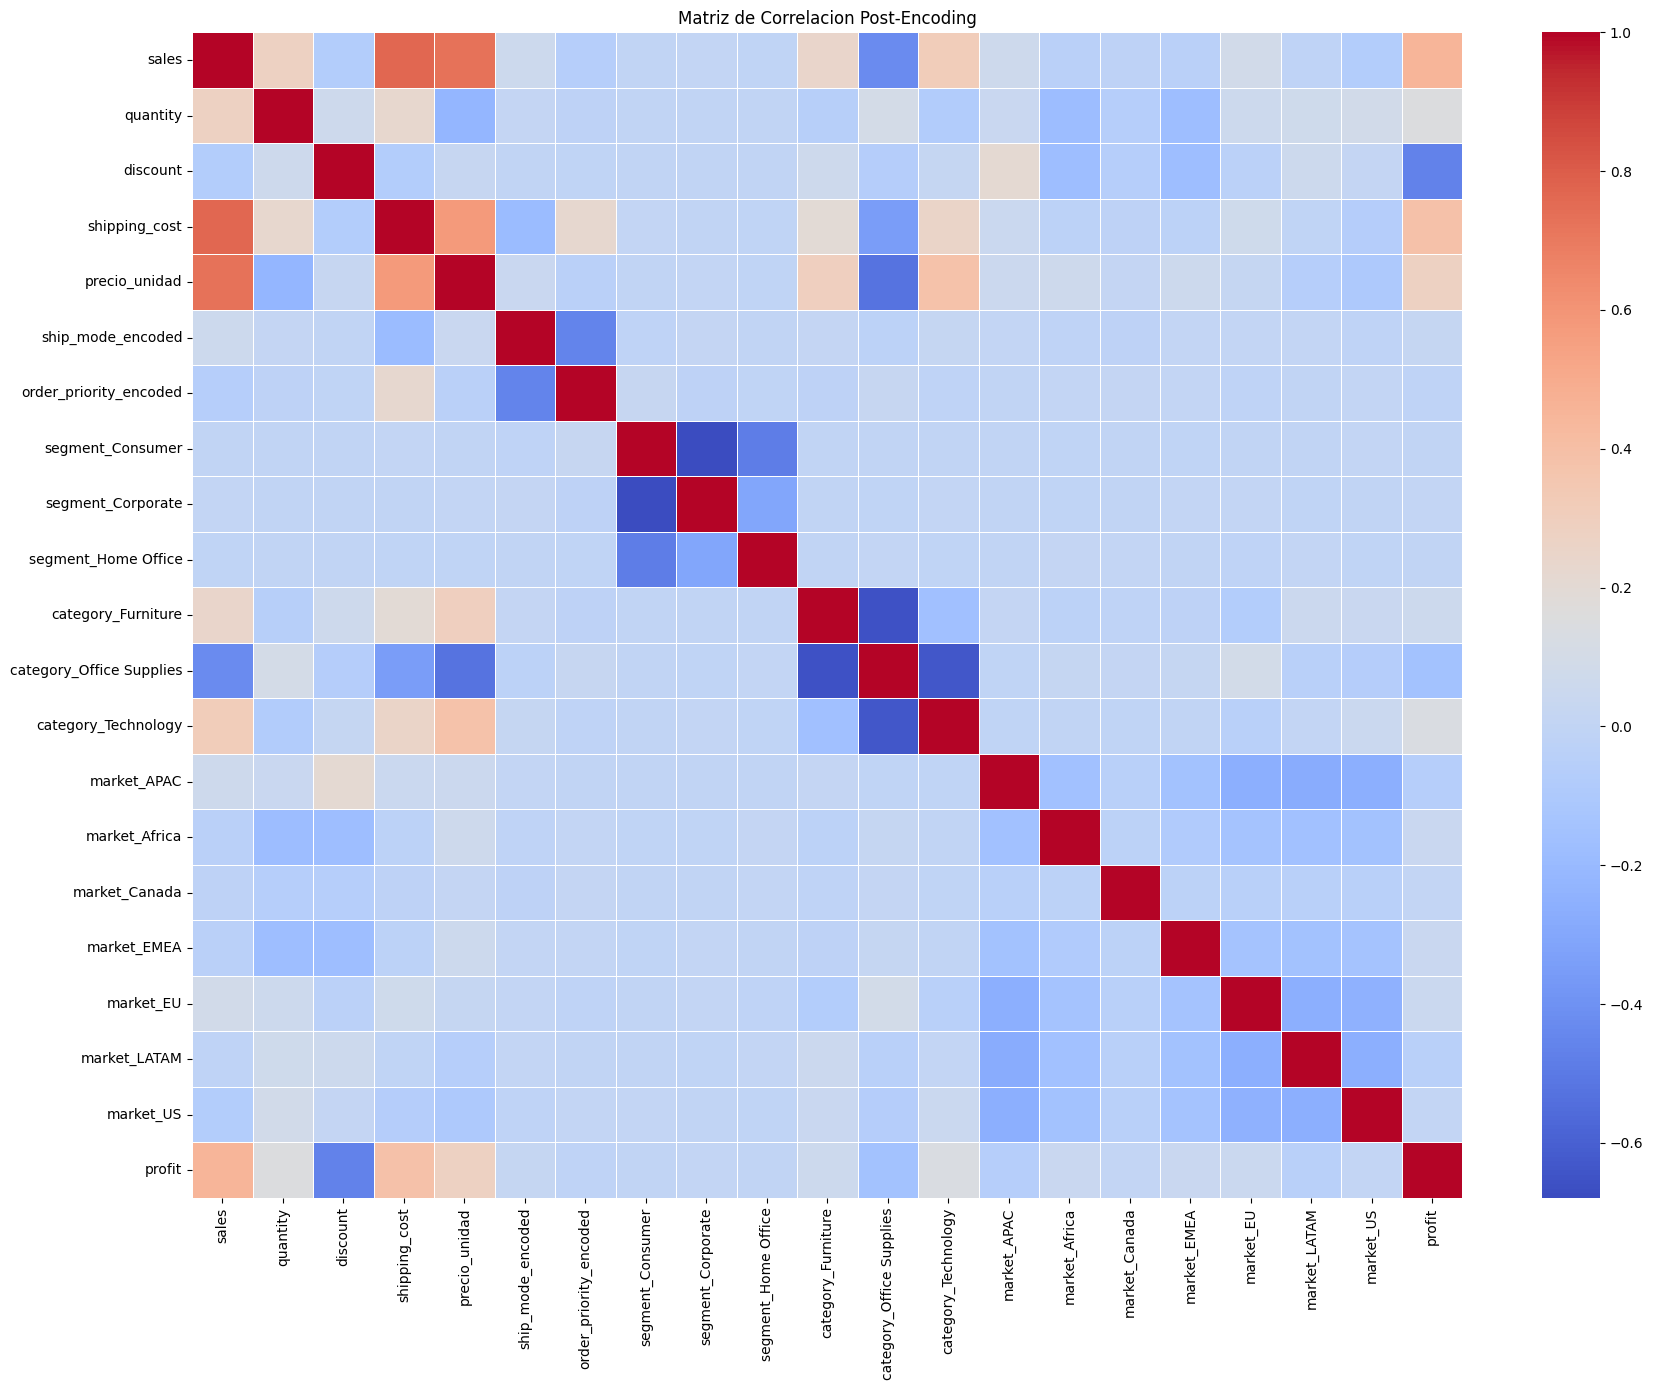

In [ ]:
# Matriz de correlacion posterior al encoding
dummy_cols = [
    col for col in df_encoded.columns
    if col.startswith('segment_') or col.startswith('category_') or col.startswith('market_')
]

numerical_and_encoded_cols = [
    'sales', 'quantity', 'discount', 'shipping_cost', 'precio_unidad',
    'ship_mode_encoded', 'order_priority_encoded',
    *dummy_cols,
    'profit'
]

correlation_matrix_full = df_encoded[numerical_and_encoded_cols].corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix_full, annot=False, cmap='coolwarm', linewidths=.4)
plt.title('Matriz de Correlacion Post-Encoding')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Cierre de criterio de exito: top 3 factores + hipotesis de negocio para Evaluacion 2
if 'correlation_matrix_full' not in globals():
    raise ValueError("No existe correlation_matrix_full. Ejecuta primero la celda de matriz de correlacion post-encoding.")

# Correlacion con profit (excluyendo la variable objetivo)
corr_profit = (
    correlation_matrix_full['profit']
    .drop(labels=['profit'])
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame('corr_profit')
)

top3_factors = corr_profit.head(3).copy()
top3_factors['direccion'] = top3_factors['corr_profit'].apply(lambda x: 'positiva' if x > 0 else 'negativa')
top3_factors['intensidad_abs'] = top3_factors['corr_profit'].abs()

print('Top 3 factores con mayor relacion (valor absoluto) con profit:')
display(top3_factors)

print('\nHipotesis de negocio para Evaluacion 2:')
for factor, row in top3_factors.iterrows():
    efecto = 'aumentar' if row['corr_profit'] > 0 else 'disminuir'
    print(f"- Si gestionamos '{factor}', el profit tenderia a {efecto} (corr={row['corr_profit']:.3f}).")

print("\nNota metodologica: estos hallazgos son correlacionales y deben validarse en modelado.")

Top 3 factores con mayor relacion (valor absoluto) con profit:


,corr_profit,direccion,intensidad_abs
discount,-0.464095,negativa,0.464095
sales,0.452642,positiva,0.452642
shipping_cost,0.385925,positiva,0.385925



Hipotesis de negocio para Evaluacion 2:
- Si gestionamos 'discount', el profit tenderia a disminuir (corr=-0.464).
- Si gestionamos 'sales', el profit tenderia a aumentar (corr=0.453).
- Si gestionamos 'shipping_cost', el profit tenderia a aumentar (corr=0.386).

Nota metodologica: estos hallazgos son correlacionales y deben validarse en modelado.


Hasta aqui llega le evaluacion 1.

#Evaluacion 2 Modelado predictivo de rentabilidad

En esta seccion transformamos el problema de regresion (`profit`) a clasificacion binaria con la variable objetivo `rentable`:

- `rentable = 1` si `profit > 0`
- `rentable = 0` si `profit <= 0`

El enfoque sigue los pilares solicitados: preparacion de datos, entrenamiento de 3 modelos base de clasificacion, analisis comparativo de metricas y bitacora tecnica de resolucion de problemas.

In [ ]:
# Preparacion de datos (X, y)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

if 'df_encoded' not in globals():
    raise ValueError("No existe df_encoded. Ejecuta primero las celdas de encoding de la Evaluacion 1.")

# Copia de trabajo para no alterar el DataFrame original
modelo_df = df_encoded.copy()

# Crear variable objetivo binaria: rentable (1) vs no rentable (0)
modelo_df['rentable'] = (modelo_df['profit'] > 0).astype(int)

# Construir lista de variables categoricas codificadas (dummies)
dummy_cols_modelo = [
    col for col in modelo_df.columns
    if col.startswith('segment_') or col.startswith('category_') or col.startswith('market_')
]

# Variables explicativas clave del negocio solicitadas por el docente
feature_cols = [
    'discount', 'sales', 'shipping_cost', 'quantity', 'year',
    'ship_mode_encoded', 'order_priority_encoded',
    *dummy_cols_modelo
]

# Normalizar columnas numericas para evitar errores por formatos texto con comas
columnas_numericas_base = [
    'discount', 'sales', 'shipping_cost', 'quantity',
    'year', 'ship_mode_encoded', 'order_priority_encoded'
]
for col in columnas_numericas_base:
    modelo_df[col] = pd.to_numeric(
        modelo_df[col].astype(str).str.replace(',', '', regex=False),
        errors='coerce'
    )

X = modelo_df[feature_cols].copy()
y = modelo_df['rentable'].copy()

# Validacion de calidad: revisar nulos antes de entrenar
nulos_features_antes = X.isnull().sum().sum()
if nulos_features_antes > 0:
    X = X.fillna(X.median(numeric_only=True))
nulos_features_despues = X.isnull().sum().sum()

print(f'Variables de entrada: {X.shape[1]}')
print(f'Registros totales: {X.shape[0]}')
print(f'Nulos en X antes de imputar: {nulos_features_antes}')
print(f'Nulos en X despues de imputar: {nulos_features_despues}')
print('\nDistribucion de la variable objetivo rentable (0/1):')
print(y.value_counts(normalize=True).rename('proporcion').round(4))

# Split EXACTO solicitado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=29,
    stratify=y
)

print('\nSplit aplicado -> test_size=0.2, random_state=29')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

Variables de entrada: 20
Registros totales: 35792
Nulos en X antes de imputar: 0
Nulos en X despues de imputar: 0

Distribucion de la variable objetivo rentable (0/1):
rentable
1    0.8259
0    0.1741
Name: proporcion, dtype: float64

Split aplicado -> test_size=0.2, random_state=29
X_train: (28633, 20) | X_test: (7159, 20)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Estructuras acumuladoras para la seccion de evaluacion comparativa
resultados_modelos = []
modelos_graficos = []

# La Regresion Logistica es un modelo parametrico ideal para mapear una combinacion lineal
# de predictores hacia una salida dicotomica (0 o 1), permitiendo interpretar el efecto de
# variables de negocio sobre la probabilidad de que una transaccion sea rentable.
modelo_logistico = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=29))
])
modelo_logistico.fit(X_train, y_train)

pred_logistico = modelo_logistico.predict(X_test)
proba_logistico = modelo_logistico.predict_proba(X_test)[:, 1]

print('\n' + '=' * 80)
print('MODELO 1: REGRESION LOGISTICA')
print('=' * 80)
print('\nClassification report:')
print(classification_report(y_test, pred_logistico, digits=4, zero_division=0))
print(f'Score train: {modelo_logistico.score(X_train, y_train):.4f}')
print(f'Score test:  {modelo_logistico.score(X_test, y_test):.4f}')

resultados_modelos.append({
    'Modelo': 'Regresion Logistica',
    'Accuracy': accuracy_score(y_test, pred_logistico),
    'Precision': precision_score(y_test, pred_logistico, zero_division=0),
    'Recall': recall_score(y_test, pred_logistico, zero_division=0),
    'F1 Score': f1_score(y_test, pred_logistico, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, proba_logistico),
    'Train Score': modelo_logistico.score(X_train, y_train),
    'Test Score': modelo_logistico.score(X_test, y_test)
})

modelos_graficos.append(('Regresion Logistica', pred_logistico, proba_logistico))


MODELO 1: REGRESION LOGISTICA

Classification report:
              precision    recall  f1-score   support

           0     0.6638    0.8091    0.7293      1247
           1     0.9578    0.9136    0.9352      5912

    accuracy                         0.8954      7159
   macro avg     0.8108    0.8614    0.8322      7159
weighted avg     0.9066    0.8954    0.8993      7159

Score train: 0.8902
Score test:  0.8954


In [ ]:
# Naive Bayes aplica el supuesto de independencia condicional de clase entre variables del
# negocio (por ejemplo, ventas y cantidad), simplificando el calculo probabilistico marginal
# y posterior para clasificar transacciones rentables y no rentables.
modelo_bayesiano = GaussianNB()
modelo_bayesiano.fit(X_train, y_train)

pred_bayesiano = modelo_bayesiano.predict(X_test)
proba_bayesiano = modelo_bayesiano.predict_proba(X_test)[:, 1]

print('\n' + '=' * 80)
print('MODELO 2: NAIVE BAYES (GAUSSIAN NB)')
print('=' * 80)
print('\nClassification report:')
print(classification_report(y_test, pred_bayesiano, digits=4, zero_division=0))
print(f'Score train: {modelo_bayesiano.score(X_train, y_train):.4f}')
print(f'Score test:  {modelo_bayesiano.score(X_test, y_test):.4f}')

resultados_modelos.append({
    'Modelo': 'Naive Bayes (GaussianNB)',
    'Accuracy': accuracy_score(y_test, pred_bayesiano),
    'Precision': precision_score(y_test, pred_bayesiano, zero_division=0),
    'Recall': recall_score(y_test, pred_bayesiano, zero_division=0),
    'F1 Score': f1_score(y_test, pred_bayesiano, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, proba_bayesiano),
    'Train Score': modelo_bayesiano.score(X_train, y_train),
    'Test Score': modelo_bayesiano.score(X_test, y_test)
})

modelos_graficos.append(('Naive Bayes (GaussianNB)', pred_bayesiano, proba_bayesiano))


MODELO 2: NAIVE BAYES (GAUSSIAN NB)

Classification report:
              precision    recall  f1-score   support

           0     0.4006    0.8613    0.5468      1247
           1     0.9614    0.7282    0.8287      5912

    accuracy                         0.7514      7159
   macro avg     0.6810    0.7947    0.6878      7159
weighted avg     0.8637    0.7514    0.7796      7159

Score train: 0.7515
Score test:  0.7514


In [ ]:

# Arbol de Decision


# El Arbol de Decision de clasificacion (CART) realiza particiones jerarquicas binarias y
# mutuamente excluyentes, seleccionando en cada nodo la division que maximiza la pureza de
# los nodos hoja (Gini/Entropia) para separar clases de manera interpretable.
modelo_arbol = DecisionTreeClassifier(criterion='gini', random_state=29)
modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)
proba_arbol = modelo_arbol.predict_proba(X_test)[:, 1]

print('\n' + '=' * 80)
print('MODELO 3: ARBOL DE DECISION (CART)')
print('=' * 80)
print('\nClassification report:')
print(classification_report(y_test, pred_arbol, digits=4, zero_division=0))
print(f'Score train: {modelo_arbol.score(X_train, y_train):.4f}')
print(f'Score test:  {modelo_arbol.score(X_test, y_test):.4f}')

resultados_modelos.append({
    'Modelo': 'Arbol de Decision (CART)',
    'Accuracy': accuracy_score(y_test, pred_arbol),
    'Precision': precision_score(y_test, pred_arbol, zero_division=0),
    'Recall': recall_score(y_test, pred_arbol, zero_division=0),
    'F1 Score': f1_score(y_test, pred_arbol, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, proba_arbol),
    'Train Score': modelo_arbol.score(X_train, y_train),
    'Test Score': modelo_arbol.score(X_test, y_test)
})

modelos_graficos.append(('Arbol de Decision (CART)', pred_arbol, proba_arbol))


MODELO 3: ARBOL DE DECISION (CART)

Classification report:
              precision    recall  f1-score   support

           0     0.6034    0.6504    0.6260      1247
           1     0.9250    0.9098    0.9174      5912

    accuracy                         0.8646      7159
   macro avg     0.7642    0.7801    0.7717      7159
weighted avg     0.8690    0.8646    0.8666      7159

Score train: 1.0000
Score test:  0.8646


In [ ]:
# tabla comparativa de metricas

df_resultados = pd.DataFrame(resultados_modelos).set_index('Modelo').round(4)
print('Tabla comparativa de metricas (modelos de clasificacion):')
display(df_resultados)

Tabla comparativa de metricas (modelos de clasificacion):


,Accuracy,Precision,Recall,F1 Score,ROC AUC,Train Score,Test Score
Modelo,,,,,,,
Regresion Logistica,0.8954,0.9578,0.9136,0.9352,0.9251,0.8902,0.8954
Naive Bayes (GaussianNB),0.7514,0.9614,0.7282,0.8287,0.8982,0.7515,0.7514
Arbol de Decision (CART),0.8646,0.9250,0.9098,0.9174,0.7801,1.0000,0.8646


In [ ]:
# seleccion del mejor modelo

mejor_nombre = df_resultados['F1 Score'].idxmax()
mejor_metricas = df_resultados.loc[mejor_nombre]

print('=' * 65)
print('MEJOR MODELO SELECCIONADO (criterio principal: F1 Score)')
print('=' * 65)
print(f'Modelo:    {mejor_nombre}')
print(f'Accuracy:  {mejor_metricas["Accuracy"]:.4f}')
print(f'Precision: {mejor_metricas["Precision"]:.4f}')
print(f'Recall:    {mejor_metricas["Recall"]:.4f}')
print(f'F1 Score:  {mejor_metricas["F1 Score"]:.4f}')
print(f'ROC AUC:   {mejor_metricas["ROC AUC"]:.4f}')
print(f'Train:     {mejor_metricas["Train Score"]:.4f}')
print(f'Test:      {mejor_metricas["Test Score"]:.4f}')
print('=' * 65)

print('\nJustificacion tecnica:')
print(
    f'Se selecciona {mejor_nombre} porque maximizó el F1 Score, metrica clave para balancear '
    f'precision y recall en presencia de desbalance entre transacciones rentables y no rentables.'
)

# Diagnostico de sobreajuste comparando desempeno train vs test
print('\nDiagnostico de sobreajuste (Train vs Test):')
for modelo, fila in df_resultados.iterrows():
    gap = fila['Train Score'] - fila['Test Score']
    estado = 'posible sobreajuste' if gap > 0.08 else 'generalizacion razonable'
    print(f"- {modelo}: gap={gap:.4f} -> {estado}")

MEJOR MODELO SELECCIONADO (criterio principal: F1 Score)
Modelo:    Regresion Logistica
Accuracy:  0.8954
Precision: 0.9578
Recall:    0.9136
F1 Score:  0.9352
ROC AUC:   0.9251
Train:     0.8902
Test:      0.8954

Justificacion tecnica:
Se selecciona Regresion Logistica porque maximizó el F1 Score, metrica clave para balancear precision y recall en presencia de desbalance entre transacciones rentables y no rentables.

Diagnostico de sobreajuste (Train vs Test):
- Regresion Logistica: gap=-0.0052 -> generalizacion razonable
- Naive Bayes (GaussianNB): gap=0.0001 -> generalizacion razonable
- Arbol de Decision (CART): gap=0.1354 -> posible sobreajuste


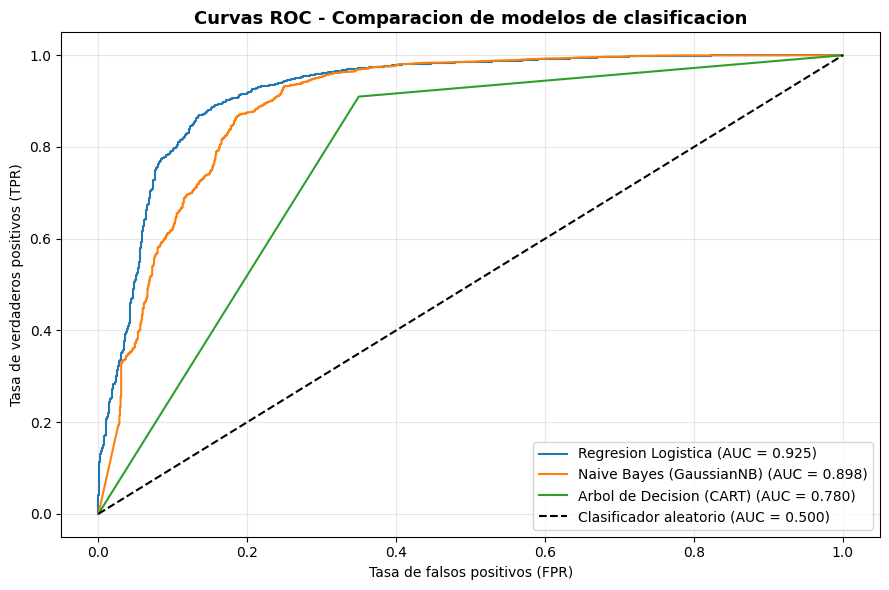

In [ ]:

# 3) Evaluation: curvas ROC (modelos de clasificacion)

plt.figure(figsize=(9, 6))

for nombre, _, proba in modelos_graficos:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.500)')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curvas ROC - Comparacion de modelos de clasificacion', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

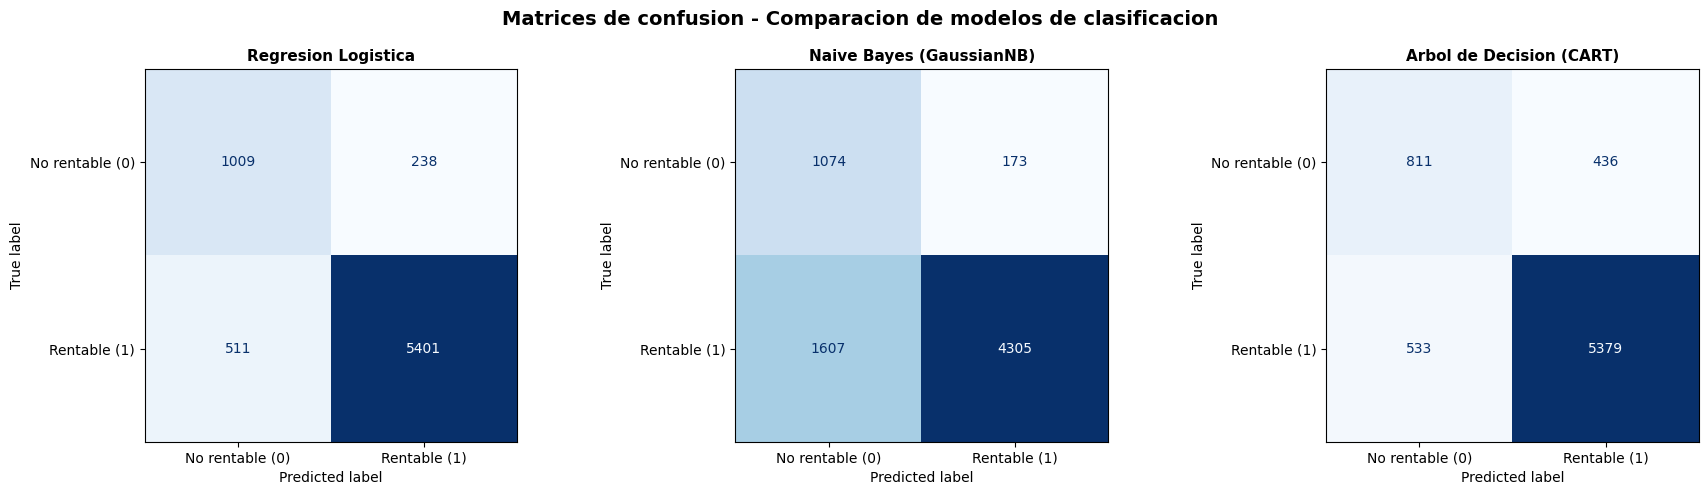

In [ ]:

# Evaluation: matrices de confusion

n_modelos = len(modelos_graficos)
fig, axes = plt.subplots(1, n_modelos, figsize=(6 * n_modelos, 5))

if n_modelos == 1:
    axes = [axes]

for ax, (nombre, pred, _) in zip(axes, modelos_graficos):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No rentable (0)', 'Rentable (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=11, fontweight='bold')

plt.suptitle('Matrices de confusion - Comparacion de modelos de clasificacion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Cuadro comparativo interpretativo (Evaluacion 2)

Se compararon 3 algoritmos de clasificacion base: Regresion Logistica, Naive Bayes y Arbol de Decision (CART).

Para los modelos de clasificacion se evaluo:
- Matriz de confusion para analizar errores por clase.
- Precision, Recall y F1-Score para la clase `rentable = 1`.
- Score de entrenamiento y prueba para diagnosticar sobreajuste.

**Criterio de seleccion del mejor clasificador:** mayor F1-Score en la clase rentable, complementado con estabilidad entre train y test.

La conclusion final del clasificador se imprime automaticamente en la seccion de Evaluation.

# Evaluacion 3

En esta evaluacion se implementa un flujo de clustering con K-Means para segmentar transacciones de negocio y apoyar decisiones operativas.

Bloques desarrollados:
1. Segmentacion no supervisada con K-Means y Metodo del Codo.
2. Evaluacion intrinseca del agrupamiento con Silhouette y Calinski-Harabasz.
3. Preparacion de salida para tableros BI (Power BI / Looker Studio).
4. Exportacion del modelo en formato `.pkl` para integracion en despliegue.

### Paso 1 - Lectura de Variables para Clustering

En este bloque se construye la matriz de entrada del clustering con las variables del negocio ya definidas en la evaluación anterior.

- Se preserva coherencia metodológica reutilizando las mismas variables predictoras.
- Se aplica limpieza numérica defensiva e imputación de nulos.
- Se estandariza para evitar sesgo por escalas diferentes en distancia euclidiana.

In [ ]:

# 1) Preparacion de datos para K-Means

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import pickle

X_cluster = modelo_df[feature_cols].copy()

# Limpieza defensiva por si aparece formato numerico con comas o valores no numericos
for col in ['discount', 'sales', 'shipping_cost', 'quantity', 'year', 'ship_mode_encoded', 'order_priority_encoded']:
    if col in X_cluster.columns:
        X_cluster[col] = pd.to_numeric(X_cluster[col].astype(str).str.replace(',', '', regex=False), errors='coerce')

X_cluster = X_cluster.fillna(X_cluster.median(numeric_only=True))

# Estandarizamos para evitar que variables de mayor escala dominen la distancia euclidiana
scaler_kmeans = StandardScaler()
X_cluster_scaled = scaler_kmeans.fit_transform(X_cluster)

print(f"Matriz para clustering: {X_cluster.shape}")
print("Datos preparados y escalados para K-Means.")

Matriz para clustering: (35792, 20)
Datos preparados y escalados para K-Means.


### Paso 2 - Justificación de K con Método del Codo

Aquí se evalúa la inercia (WCSS) para varios valores de K y se identifica el punto de inflexión.

- A menor inercia, mejor ajuste interno; pero aumentar K siempre reduce WCSS.
- El objetivo es balancear simplicidad y calidad de segmentación.
- Se selecciona K óptimo cuando la mejora marginal empieza a disminuir (el codo).

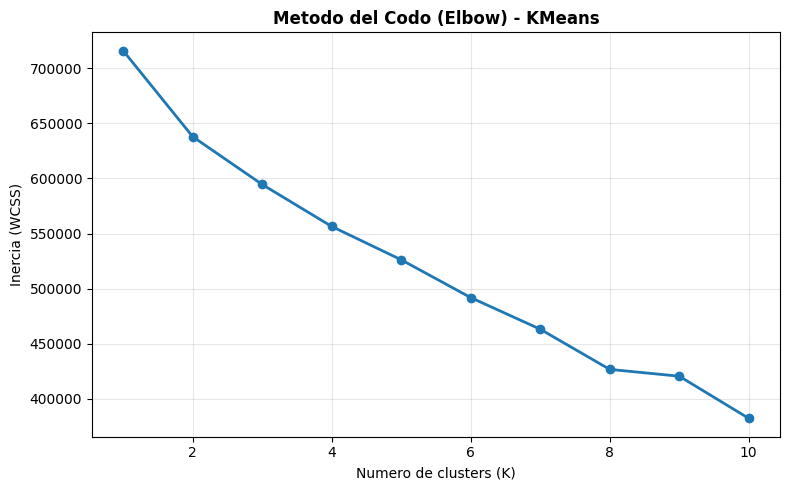

K seleccionado para el modelo final: 3


In [ ]:
# Metodo del Codo

inercias = []
rango_k = range(1, 11)

for k in rango_k:
    modelo_codo = KMeans(n_clusters=k, random_state=29, n_init=10)
    modelo_codo.fit(X_cluster_scaled)
    inercias.append(modelo_codo.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(rango_k), inercias, marker='o', linewidth=2)
plt.title('Metodo del Codo (Elbow) - KMeans', fontsize=12, fontweight='bold')
plt.xlabel('Numero de clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Seleccion de K optimo basada en la lectura visual del codo del negocio.
# Se adopta K=3 para segmentar en perfiles operativos accionables.
K_OPTIMO = 3
print(f"K seleccionado para el modelo final: {K_OPTIMO}")

### Paso 3 - Entrenamiento Final y Validación Intrínseca

Con el K seleccionado, se entrena el modelo final y se crean etiquetas de cluster.

- Silhouette evalúa cohesión y separación entre grupos en rango de -1 a +1.
- Calinski-Harabasz compara dispersión interna vs separación entre clusters.
- El resultado permite validar que el agrupamiento es utilizable para decisiones.

In [ ]:

# Entrenamiento K-Means final y metricas de rendimiento


kmeans_model = KMeans(n_clusters=K_OPTIMO, random_state=29, n_init=10)
clusters = kmeans_model.fit_predict(X_cluster_scaled)

# Etiquetas finales de segmentacion sobre el dataset de trabajo
modelo_df['cluster_rentabilidad'] = clusters

# El Coeficiente de Silueta mide la densidad/cohesion interna y separacion entre clusters.
# Toma valores en [-1, +1], donde valores cercanos a +1 reflejan mejor segmentacion.
silhouette = silhouette_score(X_cluster_scaled, clusters)

# El indice de Calinski-Harabasz evalua la razon BGSS/WGSS:
# mayor separacion entre clusters y menor dispersion interna implica mejor agrupamiento.
calinski_harabasz = calinski_harabasz_score(X_cluster_scaled, clusters)

print("Metricas de validacion intrinseca del clustering:")
print(f"- Silhouette Score: {silhouette:.4f}")
print(f"- Calinski-Harabasz Index: {calinski_harabasz:.4f}")
print("\nColumna creada en el DataFrame: cluster_rentabilidad")

Metricas de validacion intrinseca del clustering:
- Silhouette Score: 0.0929
- Calinski-Harabasz Index: 3650.7168

Columna creada en el DataFrame: cluster_rentabilidad


In [ ]:
# Exportacion para BI (Looker / Power BI)

# Se exporta el dataset final con el cluster para visualizacion externa en BI.
dataset_final_looker = modelo_df.copy()
dataset_final_looker.to_csv('dataset_final_looker.csv', index=False, encoding='utf-8-sig')

print('Archivo exportado: dataset_final_looker.csv')
print('La visualizacion y el analisis de negocio se realizan en el dashboard BI.')

Archivo exportado: dataset_final_looker.csv
La visualizacion y el analisis de negocio se realizan en el dashboard BI.


### Paso 5 - Despliegue del modelo en produccion

En esta etapa convertimos el modelo en un servicio consumible por negocio:

1. Se guardan artefactos del modelo en formato `.pkl`.
2. Se crean plantillas HTML para formulario y resultado.
3. Se genera un archivo `app_eval3.py` con Flask.
4. Se deja una celda opcional para publicar temporalmente con ngrok.

Con esto, una nueva venta puede evaluarse en tiempo real antes de aprobarse.

In [ ]:

# 5.1 Guardar artefactos del modelo para produccion


import os
import pickle

# Modelo objetivo de negocio para inferencia: clasificacion de rentabilidad
# (se conserva tambien KMeans para segmentacion operativa).
os.makedirs('models', exist_ok=True)

artefacto_produccion = {
    'modelo_clasificacion': modelo_logistico if 'modelo_logistico' in globals() else None,
    'modelo_kmeans': kmeans_model,
    'escalador_kmeans': scaler_kmeans,
    'feature_cols': feature_cols,
    'k_optimo': K_OPTIMO,
    'metricas_cluster': {
        'silhouette_score': float(silhouette),
        'calinski_harabasz_score': float(calinski_harabasz)
    }
}

with open('models/modelo_rentabilidad.pkl', 'wb') as f:
    pickle.dump(artefacto_produccion, f)

print('Artefacto exportado: models/modelo_rentabilidad.pkl')
print('Listo para ser cargado por una API Flask/FastAPI en tiempo real.')

Artefacto exportado: models/modelo_rentabilidad.pkl
Listo para ser cargado por una API Flask/FastAPI en tiempo real.


In [ ]:

# 5.2 Crear plantillas HTML para la app

import os

# Crear el directorio para los archivos HTML si no existe
os.makedirs('templates', exist_ok=True)


# Plantilla: Vista Principal (Formulario de Entrada)

index_html = '''<!doctype html>
<html lang="es">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Predictor de Rentabilidad</title>
  <link rel="preconnect" href="https://fonts.googleapis.com">
  <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
  <link href="https://fonts.googleapis.com/css2?family=Poppins:wght@400;500;600;700&display=swap" rel="stylesheet">
  <style>
    :root {
      --bg-1: #f6f8fc;
      --bg-2: #eaf2ff;
      --card: #ffffff;
      --text: #1f2937;
      --muted: #6b7280;
      --primary: #0f766e;
      --primary-2: #14b8a6;
      --border: #dbe2ea;
      --shadow: 0 18px 40px rgba(31, 41, 55, 0.10);
      --radius: 18px;
    }

    * { box-sizing: border-box; }

    body {
      margin: 0;
      font-family: 'Poppins', sans-serif;
      color: var(--text);
      background:
        radial-gradient(circle at 10% 10%, #dff4ff 0, transparent 36%),
        radial-gradient(circle at 90% 85%, #d8ffe7 0, transparent 34%),
        linear-gradient(135deg, var(--bg-1), var(--bg-2));
      min-height: 100vh;
      display: grid;
      place-items: center;
      padding: 24px;
    }

    .card {
      width: min(980px, 100%);
      background: var(--card);
      border: 1px solid var(--border);
      border-radius: var(--radius);
      box-shadow: var(--shadow);
      overflow: hidden;
    }

    .header {
      padding: 28px 28px 10px;
      background: linear-gradient(120deg, #ecfeff, #f0fdf4);
      border-bottom: 1px solid var(--border);
    }

    .header h2 {
      margin: 0;
      font-size: 1.45rem;
      line-height: 1.2;
    }

    .header p {
      margin: 10px 0 0;
      color: var(--muted);
      font-size: 0.95rem;
    }

    .body {
      padding: 22px 28px 28px;
    }

    .row {
      display: grid;
      grid-template-columns: repeat(2, minmax(0, 1fr));
      gap: 14px;
    }

    .field {
      display: flex;
      flex-direction: column;
      gap: 6px;
    }

    label {
      font-size: 0.86rem;
      color: #334155;
      font-weight: 600;
    }

    input {
      width: 100%;
      border: 1px solid var(--border);
      border-radius: 12px;
      padding: 11px 12px;
      font-size: 0.95rem;
      background: #fcfdff;
      transition: border-color .2s ease, box-shadow .2s ease;
    }

    input:focus {
      outline: none;
      border-color: var(--primary-2);
      box-shadow: 0 0 0 4px rgba(20, 184, 166, 0.15);
    }

    .hint {
      margin: 14px 0 18px;
      color: var(--muted);
      font-size: 0.84rem;
      line-height: 1.45;
      background: #f8fafc;
      border: 1px dashed #cbd5e1;
      border-radius: 12px;
      padding: 10px 12px;
    }

    button {
      border: none;
      border-radius: 12px;
      background: linear-gradient(90deg, var(--primary), var(--primary-2));
      color: white;
      font-size: 0.95rem;
      font-weight: 600;
      padding: 12px 16px;
      cursor: pointer;
      transition: transform .15s ease, filter .2s ease;
    }

    button:hover { filter: brightness(1.03); }
    button:active { transform: translateY(1px); }

    @media (max-width: 760px) {
      .header, .body { padding: 20px; }
      .row { grid-template-columns: 1fr; }
    }
  </style>
</head>
<body>
  <div class="card">
    <div class="header">
      <h2>Predictor de Rentabilidad</h2>
      <p>Ingresa las variables de una venta para estimar su rentabilidad y segmento operativo.</p>
    </div>

    <div class="body">
      <form method="POST" action="/result">
        <div class="row">
          <div class="field"><label>Descuento</label><input type="number" step="0.0001" name="discount" required></div>
          <div class="field"><label>Ventas</label><input type="number" step="0.01" name="sales" required></div>
          <div class="field"><label>Costo Envío</label><input type="number" step="0.01" name="shipping_cost" required></div>
          <div class="field"><label>Cantidad</label><input type="number" step="1" name="quantity" required></div>
          <div class="field"><label>Año</label><input type="number" step="1" name="year" required></div>
          <div class="field"><label>Modo de envio</label><input type="number" step="1" name="ship_mode_encoded" required></div>
          <div class="field"><label>Prioridad de la orden</label><input type="number" step="1" name="order_priority_encoded" required></div>
        </div>

        <button type="submit">Predecir Rentabilidad</button>
      </form>
    </div>
  </div>
</body>
</html>'''


# Plantilla: Vista de Resultados (Inferencia)

result_html = '''<!doctype html>
<html lang="es">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Resultado del Modelo</title>
  <link rel="preconnect" href="https://fonts.googleapis.com">
  <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
  <link href="https://fonts.googleapis.com/css2?family=Poppins:wght@400;500;600;700&display=swap" rel="stylesheet">
  <style>
    :root {
      --ok: #047857;
      --bad: #b91c1c;
      --text: #1f2937;
      --muted: #6b7280;
      --bg: #f5f7fb;
      --card: #ffffff;
      --line: #dbe2ea;
      --radius: 18px;
      --shadow: 0 16px 36px rgba(31, 41, 55, 0.10);
    }

    * { box-sizing: border-box; }

    body {
      margin: 0;
      font-family: 'Poppins', sans-serif;
      color: var(--text);
      background:
        radial-gradient(circle at 8% 12%, #e6fff2 0, transparent 33%),
        radial-gradient(circle at 92% 88%, #e4ecff 0, transparent 33%),
        var(--bg);
      min-height: 100vh;
      display: grid;
      place-items: center;
      padding: 22px;
    }

    .card {
      width: min(760px, 100%);
      background: var(--card);
      border: 1px solid var(--line);
      border-radius: var(--radius);
      box-shadow: var(--shadow);
      padding: 24px;
    }

    h2 {
      margin: 0 0 14px;
      font-size: 1.35rem;
    }

    .grid {
      display: grid;
      grid-template-columns: repeat(3, minmax(0, 1fr));
      gap: 10px;
      margin-top: 8px;
    }

    .tile {
      border: 1px solid var(--line);
      border-radius: 12px;
      padding: 10px;
      background: #fbfcfe;
    }

    .label {
      color: var(--muted);
      font-size: 0.78rem;
      margin-bottom: 6px;
    }

    .value {
      font-size: 1rem;
      font-weight: 700;
    }

    .ok { color: var(--ok); }
    .bad { color: var(--bad); }

    a {
      display: inline-block;
      margin-top: 16px;
      text-decoration: none;
      color: #0f766e;
      font-weight: 600;
    }

    @media (max-width: 760px) {
      .grid { grid-template-columns: 1fr; }
    }
  </style>
</head>
<body>
  <div class="card">
    <h2>Métricas de Negocio</h2>

    {% if error %}
      <p class="bad"><b>Error en la solicitud:</b> {{ error }}</p>
    {% else %}
      <div class="grid">
        <div class="tile">
          <div class="label">Predicción de Rentabilidad</div>
          <div class="value {% if resultado.prediccion == 'Rentable' %}ok{% else %}bad{% endif %}">
            {{ resultado.prediccion }}
          </div>
        </div>

        <div class="tile">
          <div class="label">Rentable</div>
          <div class="value">{{ resultado.probabilidad }}%</div>
        </div>

        <div class="tile">
          <div class="label">Clúster Estimado (K-Means)</div>
          <div class="value">{{ resultado.cluster }}</div>
        </div>
      </div>
    {% endif %}

    <a href="/">← Volver al formulario</a>
  </div>
</body>
</html>'''


# Escritura física de archivos en el sistema

with open('templates/index.html', 'w', encoding='utf-8') as f:
    f.write(index_html)

with open('templates/result.html', 'w', encoding='utf-8') as f:
    f.write(result_html)

print(' Plantillas creadas con éxito:')
print('   -> templates/index.html')
print('   -> templates/result.html')

 Plantillas creadas con éxito:
   -> templates/index.html
   -> templates/result.html


In [ ]:

# 5.3 Generar app Flask (app_eval3.py)

app_content = '''from flask import Flask, render_template, request
import pickle
import pandas as pd

app = Flask(__name__, template_folder='templates')

with open('models/modelo_rentabilidad.pkl', 'rb') as f:
    artefacto = pickle.load(f)

modelo_clf = artefacto.get('modelo_clasificacion')
modelo_kmeans = artefacto.get('modelo_kmeans')
escalador_kmeans = artefacto.get('escalador_kmeans')
feature_cols = artefacto.get('feature_cols', [])

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/result', methods=['POST'])
def result():
    try:
        base = {
            'discount': float(request.form.get('discount', 0)),
            'sales': float(request.form.get('sales', 0)),
            'shipping_cost': float(request.form.get('shipping_cost', 0)),
            'quantity': float(request.form.get('quantity', 0)),
            'year': float(request.form.get('year', 0)),
            'ship_mode_encoded': float(request.form.get('ship_mode_encoded', 0)),
            'order_priority_encoded': float(request.form.get('order_priority_encoded', 0))
        }

        x = pd.DataFrame([{c: 0 for c in feature_cols}])
        for k, v in base.items():
            if k in x.columns:
                x.loc[0, k] = v

        # Prediccion supervisada de rentabilidad
        pred = int(modelo_clf.predict(x)[0]) if modelo_clf is not None else -1
        proba = float(modelo_clf.predict_proba(x)[0, 1]) if modelo_clf is not None else 0.0

        # Segmentacion no supervisada con KMeans
        x_scaled = escalador_kmeans.transform(x)
        cluster = int(modelo_kmeans.predict(x_scaled)[0])

        resultado = {
            'prediccion': 'Rentable' if pred == 1 else 'No rentable',
            'probabilidad': round(proba * 100, 2),
            'cluster': cluster
        }
        return render_template('result.html', resultado=resultado)

    except Exception as e:
        return render_template('result.html', error=str(e))

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=False)
'''

with open('app_eval3.py', 'w', encoding='utf-8') as f:
    f.write(app_content)

print('Archivo generado: app_eval3.py')

Archivo generado: app_eval3.py


### Paso 6 - Publicacion temporal con ngrok (opcional, estilo Evaluacion Parcial)

1. Instala dependencias si no existen: `pip install flask pyngrok`.
2. Crea una cuenta gratuita en ngrok y copia tu token.
3. Ejecuta la siguiente celda para levantar la API y obtener una URL publica temporal.

In [ ]:
import os
os.environ['NGROK_AUTHTOKEN'] = '3FxTP5Ih3XfmPVaxmtG1Fkrnk1H_7zMuwk1g4BfEnZxnQLFwy'
print('NGROK_AUTHTOKEN configurado en esta sesion del kernel.')

NGROK_AUTHTOKEN configurado en esta sesion del kernel.


In [ ]:
!pip install pyngrok flask

In [ ]:
from pyngrok import ngrok

ngrok.kill()

In [ ]:
import threading
import subprocess
import sys

def run_app():
    subprocess.run([sys.executable, "app_eval3.py"])

threading.Thread(target=run_app, daemon=True).start()

In [ ]:
from pyngrok import ngrok, conf
import os

conf.get_default().auth_token = os.environ["NGROK_AUTHTOKEN"]

public_url = ngrok.connect(5000)

print(public_url)

NgrokTunnel: "https://happiness-payroll-skewer.ngrok-free.dev" -> "http://localhost:5000"
